In [ ]:
#@@
# this file was fetched from ~/work/GETM/script_ms2/wave_analysis/wave_data_crm-long_rec_v2.ipynb
# focus on 1 tag: No. 225662

In [ ]:
import pandas as pd
import xarray as xr
import numpy as np
import netCDF4
# import nc_time_axis
import matplotlib.pyplot as plt
import glob
import cmocean
import xskillscore as xs
import datetime
# from sklearn.metrics import mean_squared_error

import h5py
from scipy.io import loadmat
from scipy import signal
from scipy.interpolate import griddata
import cartopy.crs as ccrs

In [2]:
## Working directory
wrk_dir = '~/work/OBS/dashcams_data/peru_data_acc/'

# 1. for the fist step, check the configuration file 

In [3]:
config_tag = pd.read_csv(wrk_dir+'Multiselect_devsettings_20250224_223500.csv')
config_tag

,device_id,UTC_datetime,UTC_date,UTC_time,settings_count,Divelink GPS max burst divider,Divelink GPS max burst divider.1,Divelink GPS max burst divider.2,Divelink GPS max burst,Divelink GPS max burst.1,...,GF2_R9_BR_LAT,GF2_R9_BR_LON,GF2_R10_TL_LAT,GF2_R10_TL_LON,GF2_R10_BR_LAT,GF2_R10_BR_LON,GPS fix timeout,GPS fix timeout GF1,GPS fix timeout GF2,Unnamed: 193
0,225660,2025-01-22 07:07:32,2025-01-22,07:07:32,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,225660,2025-02-11 07:10:22,2025-02-11,07:10:22,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,225660,CURRENT SETTINGS,2025-02-24,22:36:03,CURRENT SETTINGS,50.0,1.0,1.0,15.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90.0,90.0,90.0,NaN
3,225661,2025-01-25 07:29:53,2025-01-25,07:29:53,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,225661,2025-02-11 19:29:50,2025-02-11,19:29:50,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,225661,2025-02-20 07:29:47,2025-02-20,07:29:47,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,225661,CURRENT SETTINGS,2025-02-24,22:36:03,CURRENT SETTINGS,50.0,1.0,1.0,15.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90.0,90.0,90.0,NaN
7,225662,2025-01-25 02:55:44,2025-01-25,02:55:44,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,225662,2025-01-28 02:55:51,2025-01-28,02:55:51,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,225662,2025-02-11 02:56:18,2025-02-11,02:56:18,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. load raw data

## (1) read data from CSV (((can use NC file below directly)))

In [186]:
file1=wrk_dir+'wave_acc/PERU_acc_raw_longrec_keepGPS_225662_v1.csv'; ptime=165
# file1='surf_processed/Jul_Sep_2021.csv'; ptime=220
# file1='surf_processed/Oct_Dec_2021.csv'

# yr=file1[-21:-17]
# yr=file1[-13:-9]
df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')

In [187]:
df[(pd.to_datetime(df['date'])>=pd.to_datetime('2025-4-24 3:36'))&(pd.to_datetime(df['date'])<=pd.to_datetime('2025-4-30 9:42'))]

,device_id,UTC_date,UTC_time,datatype,satcount,Latitude,Longitude,acc_x,acc_y,acc_z,UTC_timestamp,milliseconds,depth_m,date
UTC_datetime,,,,,,,,,,,,,,
2025-04-24 04:26:24,225662,2025-04-24,04:26:24,GPSS,7.0,-7.814837,-79.499451,112,-838,603,2025-04-24 04:26:24.000,0,NaN,2025-04-24 04:26:24
2025-04-24 06:26:13,225662,2025-04-24,06:26:13,GPSS,5.0,-7.815072,-79.499214,-371,-787,525,2025-04-24 06:26:13.979,979,NaN,2025-04-24 06:26:13
2025-04-24 08:26:11,225662,2025-04-24,08:26:11,GPSS,9.0,-7.814855,-79.498772,-63,-875,529,2025-04-24 08:26:11.040,40,NaN,2025-04-24 08:26:11
2025-04-24 10:11:13,225662,2025-04-24,10:11:13,GPS,5.0,-7.814738,-79.499130,-369,-817,487,2025-04-24 10:11:13.000,0,NaN,2025-04-24 10:11:13
2025-04-24 10:25:15,225662,2025-04-24,10:25:15,GPS,5.0,-7.814794,-79.499138,-382,-797,519,2025-04-24 10:25:15.000,0,NaN,2025-04-24 10:25:15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-27 12:56:41,225662,2025-04-27,12:56:41,SEN_ACC_5Hz,NaN,NaN,NaN,-241,476,991,2025-04-27 12:56:41.090,90,NaN,2025-04-27 12:56:41
2025-04-27 12:56:41,225662,2025-04-27,12:56:41,SEN_ACC_5Hz,NaN,NaN,NaN,-279,446,889,2025-04-27 12:56:41.290,290,NaN,2025-04-27 12:56:41
2025-04-27 12:56:41,225662,2025-04-27,12:56:41,SEN_ACC_5Hz,NaN,NaN,NaN,-318,415,655,2025-04-27 12:56:41.490,490,NaN,2025-04-27 12:56:41


In [188]:
df['t'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['milliseconds'], unit='ms')

In [189]:
df['date2'] = df['t']
df = df.set_index('t')
df

,device_id,UTC_date,UTC_time,datatype,satcount,Latitude,Longitude,acc_x,acc_y,acc_z,UTC_timestamp,milliseconds,depth_m,date,date2
t,,,,,,,,,,,,,,,
2022-10-05 19:16:57.278,225662,2022-10-05,19:16:57,GPS,6.0,54.784336,25.192566,82,63,1032,2022-10-05 19:16:57.278,278,NaN,2022-10-05 19:16:57,2022-10-05 19:16:57.278
2022-10-14 21:55:06.000,225662,2022-10-14,21:55:06,GPS,5.0,44.558460,-123.271408,70,-10,1030,2022-10-14 21:55:06.000,0,NaN,2022-10-14 21:55:06,2022-10-14 21:55:06.000
2022-10-14 22:09:50.000,225662,2022-10-14,22:09:50,GPS,5.0,44.558441,-123.271332,73,-10,1025,2022-10-14 22:09:50.000,0,NaN,2022-10-14 22:09:50,2022-10-14 22:09:50.000
2022-10-14 22:25:14.000,225662,2022-10-14,22:25:14,GPS,7.0,44.558449,-123.271431,73,-6,1026,2022-10-14 22:25:14.000,0,NaN,2022-10-14 22:25:14,2022-10-14 22:25:14.000
2022-10-14 22:39:57.000,225662,2022-10-14,22:39:57,GPS,7.0,44.558498,-123.271423,71,-5,1030,2022-10-14 22:39:57.000,0,NaN,2022-10-14 22:39:57,2022-10-14 22:39:57.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-27 12:56:41.090,225662,2025-04-27,12:56:41,SEN_ACC_5Hz,NaN,NaN,NaN,-241,476,991,2025-04-27 12:56:41.090,90,NaN,2025-04-27 12:56:41,2025-04-27 12:56:41.090
2025-04-27 12:56:41.290,225662,2025-04-27,12:56:41,SEN_ACC_5Hz,NaN,NaN,NaN,-279,446,889,2025-04-27 12:56:41.290,290,NaN,2025-04-27 12:56:41,2025-04-27 12:56:41.290
2025-04-27 12:56:41.490,225662,2025-04-27,12:56:41,SEN_ACC_5Hz,NaN,NaN,NaN,-318,415,655,2025-04-27 12:56:41.490,490,NaN,2025-04-27 12:56:41,2025-04-27 12:56:41.490


In [190]:
df2=df
# df1 = df.loc[df['device_id']==203013]

# x = xr.DataArray(df.Longitude_1, dims="t")
# y = xr.DataArray(df.Latitude_1, dims="t")
time = xr.DataArray(df2.date2, dims="t")
did = xr.DataArray(df2.device_id, dims="t")
accx = xr.DataArray(df2.acc_x,dims='t')
accy = xr.DataArray(df2.acc_y,dims='t')
accz = xr.DataArray(df2.acc_z,dims='t')
lon = xr.DataArray(df2.Longitude,dims='t')
lat = xr.DataArray(df2.Latitude,dims='t')
datatype = xr.DataArray(df2.datatype,dims='t')
# depth = xr.DataArray(df2.topography,dims='t')
# temp = xr.DataArray(df.ext_temperature_C, dims="t")
# conduc = xr.DataArray(df['conductivity_mS/cm'], dims="t")

ds_obs = xr.Dataset({
    # 'x': x,
    # 'y': y,
    # 'time': time,
    'id': did,
    'accx': accx,
    'accy': accy,
    'accz': accz,
    'lon': lon,
    'lat': lat,
    'datatype': datatype,
    # 'depth': depth
    # 'temp': temp,
    # 'cond': conduc
})

In [191]:
ds_obs.to_netcdf('PERU_acc_raw_v1_keep_gps_225662.nc')

PermissionError: [Errno 13] Permission denied: b'/home/server/pi/homes/liux8/work/OBS/dashcams_data/peru_data_acc/PERU_acc_raw_v1_keep_gps_225662.nc'

## (2) load NC files

In [4]:
ds_obs = xr.open_dataset(wrk_dir+'PERU_acc_raw_v1_keep_gps_225662.nc',mode='r')
ds_obs

<xarray.Dataset>
Dimensions:   (t: 919490)
Coordinates:
  * t         (t) datetime64[ns] 2022-10-05T19:16:57.278000 ... 2025-04-23T14...
Data variables:
    id        (t) int64 ...
    accx      (t) int64 ...
    accy      (t) int64 ...
    accz      (t) int64 ...
    lon       (t) float64 ...
    lat       (t) float64 ...
    datatype  (t) object ...

# 3. find the locations of the tags in Peru Coast

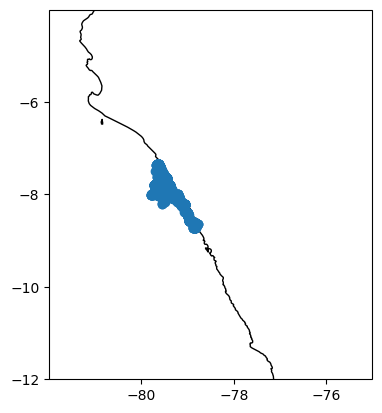

In [192]:
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs.lon,ds_obs.lat,'o')

ax.coastlines()
ax.set_xlim(-82,-75)
ax.set_ylim(-12,-4)
ax.set_xticks(np.arange(-80,-75,2), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-12,-4,2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

# Define GEO box

In [6]:
# coordinate of the box
x_geobox = [-80,-78.5]
y_geobox = [-9.2, -7.4]

In [194]:
ds_obs_peru_box = ds_obs.where((ds_obs.lon>x_geobox[0])&(ds_obs.lon<x_geobox[1])&(ds_obs.lat>y_geobox[0])&(ds_obs.lat<y_geobox[1]),drop=True)
ds_obs_peru_box

<xarray.Dataset>
Dimensions:   (t: 24120)
Coordinates:
  * t         (t) datetime64[ns] 2025-01-22T14:57:59 ... 2025-04-27T12:55:21....
Data variables:
    id        (t) float64 2.257e+05 2.257e+05 2.257e+05 ... 2.257e+05 2.257e+05
    accx      (t) float64 -111.0 -62.0 -449.0 -347.0 ... -377.0 -170.0 -286.0
    accy      (t) float64 319.0 -928.0 -881.0 -892.0 ... 211.0 263.0 84.0 146.0
    accz      (t) float64 1.053e+03 463.0 285.0 432.0 ... 862.0 925.0 995.0
    lon       (t) float64 -79.5 -79.5 -79.5 -79.5 ... -79.58 -79.58 -79.58
    lat       (t) float64 -7.814 -7.814 -7.814 -7.814 ... -7.63 -7.63 -7.63
    datatype  (t) object 'GPS' 'GPS' 'GPS' 'GPS' ... 'GPSD' 'GPS' 'GPSD' 'GPSD'

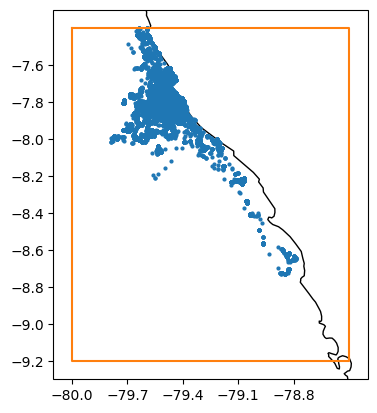

In [195]:
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs_peru_box.lon,ds_obs_peru_box.lat,'o',markersize=2)
plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])

ax.coastlines()
ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

# plotting locations by device id

## 1. find tag IDs and their locations

In [196]:
print( 'tags in the box:' , np.unique(ds_obs_peru_box.id))

tags in the box: [225662.]


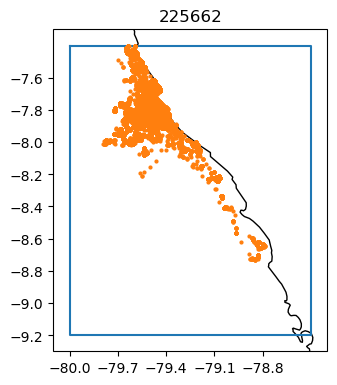

In [197]:
# ax = plt.axes(projection=ccrs.PlateCarree())
# plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])

# ax.coastlines()
# ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
# ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
fig = plt.figure(figsize=(12,10))
kk=1
for idnn in np.unique(ds_obs.id):
    ax = fig.add_subplot(2,3,kk,projection=ccrs.PlateCarree())
    kk = kk+1
    plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])
    
    ax.coastlines()
    ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
    ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
    ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
    plt.plot(ds_obs_peru_box.lon.where(ds_obs_peru_box.id==idnn),ds_obs_peru_box.lat,'o',markersize=2)
    plt.title(f'{idnn}')
    

## data in this region

In [198]:
for id in np.unique(ds_obs_peru_box.id):

    ds_obs_peru_box_singetag = ds_obs_peru_box.where(ds_obs_peru_box.id==id,drop=True)
    print(f'ID= {id} GPS signals {ds_obs_peru_box_singetag.accx.size}')

ID= 225662.0 GPS signals 24120


# calculate the total number of SEN_ALL_5HZ, SEN_ACC_5HZ, SEN_ALL_20Hz data for all tags

## (1) find types of acc signals

225662.0


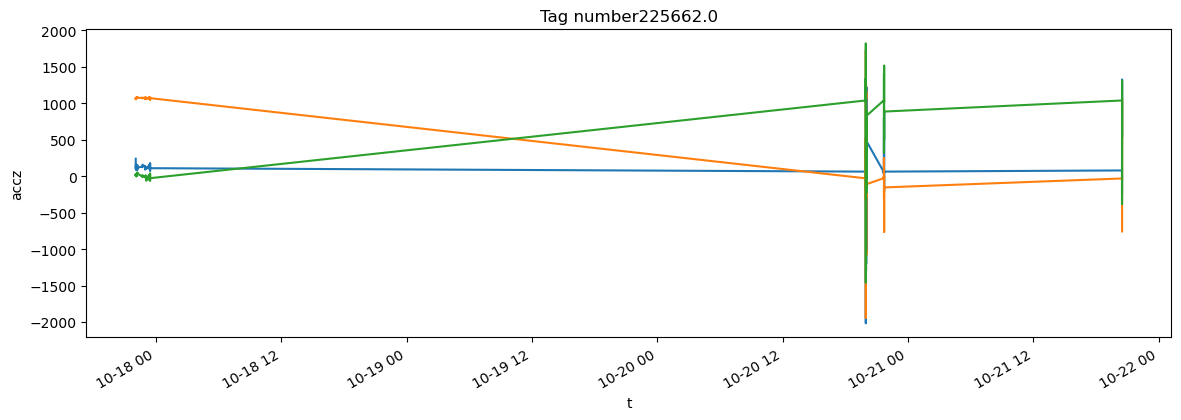

In [199]:
tag_id_sen_all_5hz = []
for idd in np.unique(ds_obs_peru_box.id):
    ds_obs_sub = ds_obs.where((ds_obs.id == idd) & (ds_obs.datatype=='SEN_ALL_5Hz'),drop=True)
    
    if ds_obs_sub.accx.size>0:
        print(idd)
        fig = plt.subplots(figsize=(14,4))
        ds_obs_sub.accx.plot(label='accx')
        ds_obs_sub.accy.plot(label='accy')
        ds_obs_sub.accz.plot(label='accz')
        plt.title('Tag number'+str(idd))
        tag_id_sen_all_5hz.append(idd)
    # print(ds_obs_sub)

225662.0


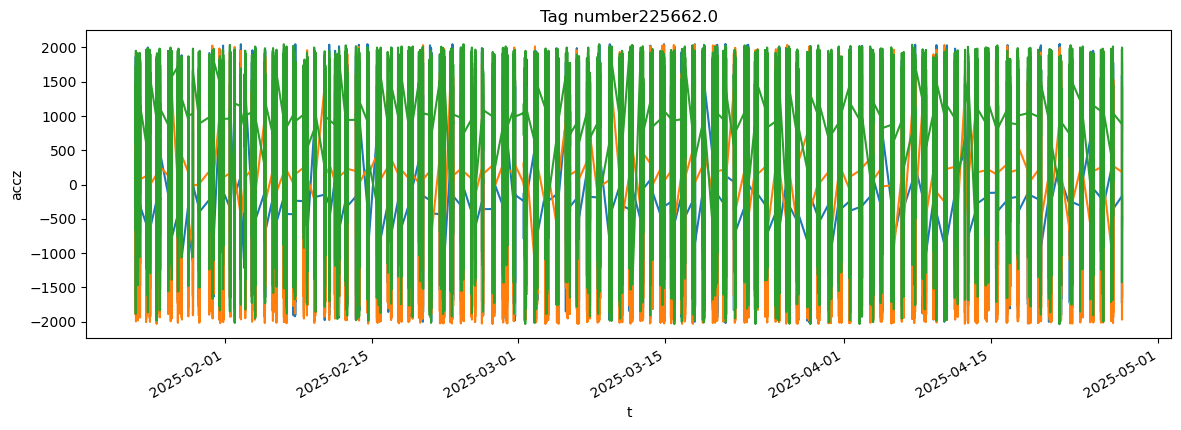

In [200]:
tag_id_sen_acc_5hz = []
for idd in np.unique(ds_obs_peru_box.id):
    ds_obs_sub = ds_obs.where((ds_obs.id == idd) & (ds_obs.datatype=='SEN_ACC_5Hz'),drop=True)
    
    if ds_obs_sub.accx.size>0:
        print(idd)
        fig = plt.subplots(figsize=(14,4))
        ds_obs_sub.accx.plot(label='accx')
        ds_obs_sub.accy.plot(label='accy')
        ds_obs_sub.accz.plot(label='accz')
        plt.title('Tag number'+str(idd))
        tag_id_sen_acc_5hz.append(idd)

In [201]:
### NO signal with SEN_ACC_20Hz!!!!!
for idd in np.unique(ds_obs_peru_box.id):
    ds_obs_sub = ds_obs.where((ds_obs.id == idd) & (ds_obs.datatype=='SEN_ACC_20Hz'),drop=True)
    
    if ds_obs_sub.accx.size>0:
        print(idd)
        fig = plt.subplots(figsize=(14,4))
        ds_obs_sub.accx.plot(label='accx')
        ds_obs_sub.accy.plot(label='accy')
        ds_obs_sub.accz.plot(label='accz')
        plt.title('Tag number'+str(idd))

In [202]:
tag_id_sen_all_20hz = []
for idd in np.unique(ds_obs_peru_box.id):
    ds_obs_sub = ds_obs.where((ds_obs.id == idd) & (ds_obs.datatype=='SEN_ALL_20Hz'),drop=True)
    
    if ds_obs_sub.accx.size>0:
        print(idd)
        fig = plt.subplots(figsize=(14,4))
        ds_obs_sub.accx.plot(label='accx')
        ds_obs_sub.accy.plot(label='accy')
        ds_obs_sub.accz.plot(label='accz')
        plt.title('Tag number'+str(idd))
        tag_id_sen_all_20hz.append(idd)

## (2) tag categories

In [203]:
print(tag_id_sen_all_5hz)
print(tag_id_sen_acc_5hz)
print(tag_id_sen_all_20hz)

[225662.0]
[225662.0]
[]


# process all tags

In [204]:
# For all tags in the box
# adding a dimnesion to the dataset (time index/ sequential number)
# move the original time to a data variable

# for idn in [np.unique(ds_obs_crm_box.id)]:
    # print(idn)

# ds_obs_1 = ds_obs.where((ds_obs.id == idn),drop=True)
# Create a new integer coordinate
new_t = np.arange(len(ds_obs['t']))

# Optionally, store the original time as a data variable for reference
ds_obs = ds_obs.assign(original_time=('time_index', ds_obs['t'].values))

# Assign the new integer coordinate while keeping the original as a variable
ds_obs = ds_obs.assign_coords(t=new_t).rename({'t': 'time_index'})

# assign a new variable 'mask' (with NaNs)
ds_obs = ds_obs.assign(mask=(('time_index',), np.full(ds_obs.dims['time_index'], np.nan)))

In [205]:
np.unique(ds_obs.datatype)

array(['GPS', 'GPSD', 'GPSS', 'SEND_ALL2_1Hz_START_END', 'SEND_ALL2_5Hz',
       'SEND_ALL2_5Hz_END', 'SEND_ALL2_5Hz_START', 'SEN_ACC_5Hz',
       'SEN_ACC_5Hz_END', 'SEN_ACC_5Hz_ENDINT', 'SEN_ACC_5Hz_START',
       'SEN_ALL_5Hz', 'SEN_ALL_5Hz_END', 'SEN_ALL_5Hz_ENDINT',
       'SEN_ALL_5Hz_START'], dtype=object)

In [206]:
gps_indices_a = ds_obs.time_index.where(ds_obs.datatype == 'GPS', drop=True).values.astype(int)
# print(gps_indices[:400])

indices = [(i, j, j-i) for i, j in zip(gps_indices_a[:-1], gps_indices_a[1:]) if j - i > 10]
imask = 0
for idx in indices:
    print(idx)
    ds_obs['mask'].loc[dict(time_index=slice(idx[0], idx[1]))] = imask
    imask = imask+1

print(imask)

(24, 6318, 6294)
(6325, 8827, 2502)
(8827, 9664, 837)
(9664, 9797, 133)
(9831, 10153, 322)
(10153, 10887, 734)
(10894, 11456, 562)
(11456, 11728, 272)
(11735, 11815, 80)
(11815, 12764, 949)
(12764, 13098, 334)
(13111, 14094, 983)
(14094, 14780, 686)
(14780, 15317, 537)
(15321, 15964, 643)
(15964, 17138, 1174)
(17145, 17533, 388)
(17533, 19111, 1578)
(19111, 20575, 1464)
(20575, 20845, 270)
(20865, 21446, 581)
(21446, 22260, 814)
(22260, 22560, 300)
(22560, 22951, 391)
(22951, 23635, 684)
(23635, 24098, 463)
(24119, 24478, 359)
(24478, 24892, 414)
(24892, 25512, 620)
(25512, 25965, 453)
(25965, 26861, 896)
(26861, 26937, 76)
(26977, 27059, 82)
(27059, 27961, 902)
(27961, 28653, 692)
(28653, 29037, 384)
(29052, 29132, 80)
(29132, 29578, 446)
(29578, 30117, 539)
(30117, 30440, 323)
(30440, 30870, 430)
(30870, 31121, 251)
(31121, 31274, 153)
(31281, 31515, 234)
(31515, 31980, 465)
(31980, 32504, 524)
(32504, 32580, 76)
(32601, 32833, 232)
(32833, 33293, 460)
(33293, 34038, 745)
(34038, 342

In [207]:
lon_lat_indices_1 = ds_obs.isel(time_index=np.array(indices)[:,0])
lon_lat_indices_1 = lon_lat_indices_1.assign_coords(index_local=("time_index", np.arange(len(lon_lat_indices_1["time_index"]))))

lon_lat_indices_2 = ds_obs.isel(time_index=np.array(indices)[:,1])
lon_lat_indices_2 = lon_lat_indices_2.assign_coords(index_local=("time_index", np.arange(len(lon_lat_indices_2["time_index"]))))

lon_lat_indices_1_in_box = lon_lat_indices_1.where(
    (lon_lat_indices_1.lon > x_geobox[0]) & (lon_lat_indices_1.lon < x_geobox[1]) &
    (lon_lat_indices_1.lat > y_geobox[0]) & (lon_lat_indices_1.lat < y_geobox[1]),
    drop=True
)
lon_lat_indices_2_in_box = lon_lat_indices_2.where(
    (lon_lat_indices_2.lon > x_geobox[0]) & (lon_lat_indices_2.lon < x_geobox[1]) &
    (lon_lat_indices_2.lat > y_geobox[0]) & (lon_lat_indices_2.lat < y_geobox[1]),
    drop=True
)
# lon_lat_indices_1_in_box

common_indices = np.intersect1d(lon_lat_indices_1_in_box.index_local, lon_lat_indices_2_in_box.index_local)


In [208]:
print(lon_lat_indices_1_in_box.where(lon_lat_indices_1_in_box.index_local==common_indices[1],drop=True).time_index.values)
print(lon_lat_indices_2_in_box.where(lon_lat_indices_2_in_box.index_local==common_indices[1],drop=True).time_index.values)

[10153]
[10887]


4 (9831, 10153) 225662 -79.49271392822266 -7.823023319244385 -79.40239715576173 -7.860538482666016
5 (10153, 10887) 225662 -79.40239715576173 -7.860538482666016 -79.41743469238281 -7.821780204772949
6 (10894, 11456) 225662 -79.4641876220703 -7.782068252563477 -79.40702056884764 -7.819501876831055
7 (11456, 11728) 225662 -79.40702056884764 -7.819501876831055 -79.49820709228516 -7.813836574554443
8 (11735, 11815) 225662 -79.49810791015625 -7.813953399658203 -79.46822357177734 -7.754876613616943
9 (11815, 12764) 225662 -79.46822357177734 -7.754876613616943 -79.43996429443358 -7.758218288421631
10 (12764, 13098) 225662 -79.43996429443358 -7.758218288421631 -79.49820709228516 -7.813950061798096
11 (13111, 14094) 225662 -79.49275970458984 -7.770748138427734 -79.48453521728516 -7.707076549530029
12 (14094, 14780) 225662 -79.48453521728516 -7.707076549530029 -79.48393249511719 -7.693841934204102
13 (14780, 15317) 225662 -79.48393249511719 -7.693841934204102 -79.46508789062499 -7.76339817047119

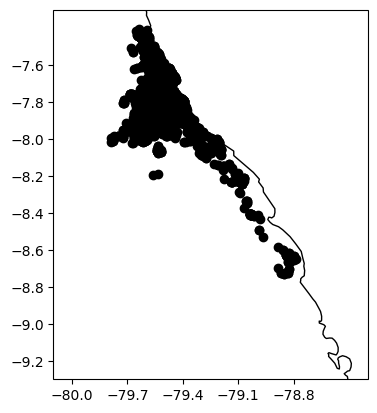

In [209]:
# Define indices_inbox list
indices_inbox_a = []
ds_obs['mask2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['x1'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['y1'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['x2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['y2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
imask = 0

ax = plt.axes(projection=ccrs.PlateCarree())
# first find the indices whose GPS location is in the box
# for idx in indices:
for idx2 in common_indices:
#     print(idx2)
    idx = (lon_lat_indices_1_in_box.where(lon_lat_indices_1_in_box.index_local==idx2,drop=True).time_index.values[0],
            lon_lat_indices_2_in_box.where(lon_lat_indices_2_in_box.index_local==idx2,drop=True).time_index.values[0])
    # p1 = ds_obs.isel(time_index=idx[0])
    p1 = ds_obs.isel(time_index=idx[0])
    p2 = ds_obs.isel(time_index=idx[1])

    # if (x_geobox[0] < p1.lon.values < x_geobox[1]) & (y_geobox[0] < p1.lat.values < y_geobox[1]) & \
    #    (x_geobox[0] < p2.lon.values < x_geobox[1]) & (y_geobox[0] < p2.lat.values < y_geobox[1]):
    #         indices_inbox_a.append(idx)
            # Check if records between idx[0] and idx[1] have the datatype SEN_ALL_1Hz_START and SEN_ALL_1Hz_END
    if 'SEN_ACC_5Hz' in ds_obs.datatype.isel(time_index=slice(idx[0], idx[1])).values:
        ds_obs['mask2'].loc[dict(time_index=slice(idx[0], idx[1]))] = xr.where(
            ds_obs.datatype.isin(['SEN_ACC_5Hz', 'SEN_ACC_5Hz_START', 'SEN_ACC_5Hz_END']).loc[dict(time_index=slice(idx[0], idx[1]))],
            imask,
            ds_obs['mask2'].loc[dict(time_index=slice(idx[0], idx[1]))]
        )
        ds_obs['x1'].loc[dict(time_index=slice(idx[0], idx[1]))] = p1.lon.values
        ds_obs['y1'].loc[dict(time_index=slice(idx[0], idx[1]))] = p1.lat.values
        ds_obs['x2'].loc[dict(time_index=slice(idx[0], idx[1]))] = p2.lon.values
        ds_obs['y2'].loc[dict(time_index=slice(idx[0], idx[1]))] = p2.lat.values
        imask += 1
        print(idx2, idx,p1.id.values,p1.lon.values, p1.lat.values,p2.lon.values, p2.lat.values)
        plt.plot([p1.lon.values,p2.lon.values], [p1.lat.values,p2.lat.values],'ok')

ax.coastlines()
# ax.set_xlim(-125,-123)
# ax.set_ylim(44,47)
# ax.set_xticks(np.arange(-124.7,-124,0.3), crs=ccrs.PlateCarree())
# ax.set_yticks(np.arange(46,47,0.2), crs=ccrs.PlateCarree())
ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

# for idx in indices:
#     # print(dfs.loc[idx[0]:idx[1]])
#     dfs_chunk = dfs.loc[idx[0]:idx[1]]
#     sen_start = dfs_chunk[(dfs_chunk['datatype'] == 'SEN_ALL_1Hz_START')]
#     sen_end = dfs_chunk[(dfs_chunk['datatype'] == 'SEN_ALL_1Hz_END')]
#     print(sen_start,sen_end)

#     if not sen_start.empty and not sen_end.empty:
#         chunk_acc = dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]
#         if 'chunk_acc' in locals():
#             chunk_acc = pd.concat([chunk_acc, dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]])
#         else:
#             chunk_acc = dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]

# LARGE chunks divided by GPS signals

In [23]:
### total number of chunks (THIS "chunk" is coarsely divided by GPS signals) in the box for acc data
len(np.unique(ds_obs.mask2))

1213

In [124]:
for ik in range(1322,1322+30):
    plt.figure(figsize=(14,4))
    plt.plot(ds_obs.where(ds_obs.mask2==ik+1,drop=True).original_time,ds_obs.where(ds_obs.mask2==ik+1,drop=True).accz)
    # ds_obs.where(ds_obs.mask2==ik+1,drop=True).accz.plot()
    plt.title(f'Tag number {ds_obs.where(ds_obs.mask2==ik+1, drop=True).id.values[0]} - {ik+1}')
    plt.savefig(f'figure_all/tag_{int(ds_obs.where(ds_obs.mask2==ik+1, drop=True).id.values[0])}_{ik+1}.png')
    plt.close()

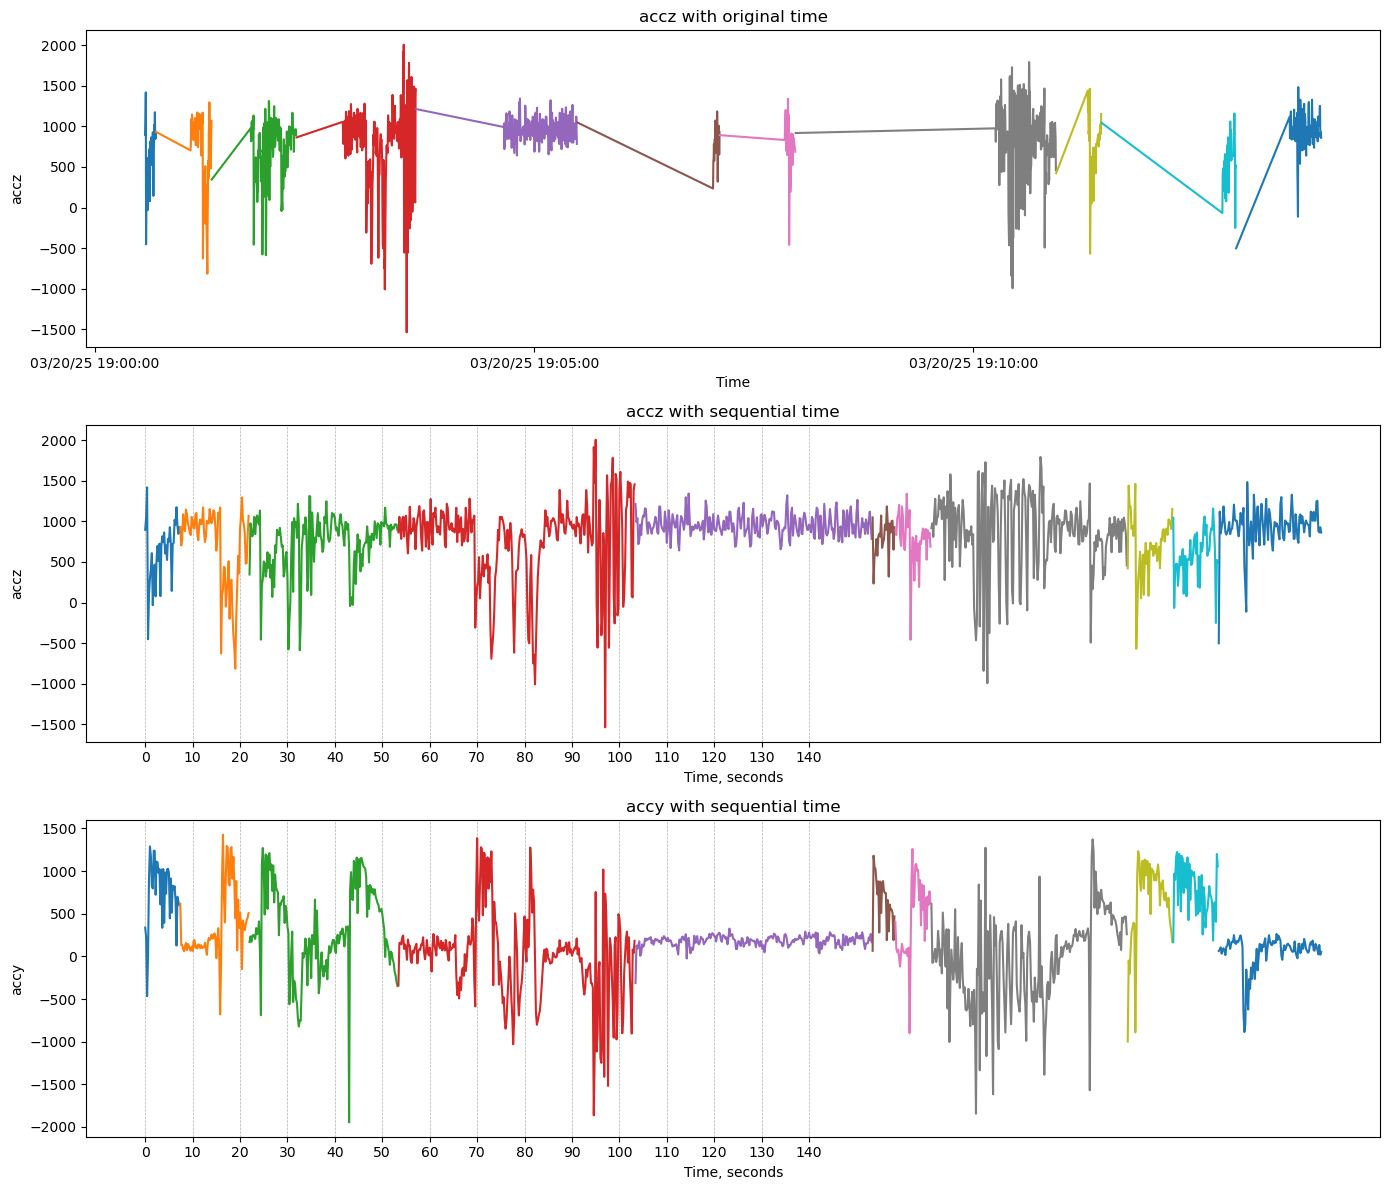

In [25]:
ik = 800

data_chunk_8 = ds_obs.where(ds_obs.mask2 == ik + 1, drop=True)

# Calculate the time difference between consecutive points
time_diff = data_chunk_8.original_time.diff(dim='time_index').astype('timedelta64[s]')

# Find the indices where the time difference is greater than 2 seconds
cut_indices = np.where(time_diff > np.timedelta64(2, 's'))[0]

# Split the data_chunk_8 into pieces based on the cut_indices
data_pieces = [data_chunk_8.isel(time_index=slice(start, end)) for start, end in zip(np.r_[0, cut_indices], np.r_[cut_indices, len(data_chunk_8.time_index)])]

fig, axs = plt.subplots(3, 1, figsize=(14, 12))

# Plot accz with original time
colors = plt.cm.viridis(np.linspace(0, 1, len(data_pieces)))
for i, piece in enumerate(data_pieces):
    axs[0].plot(piece['original_time'], piece['accz'])
axs[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%D %H:%M:%S'))
axs[0].set_xlabel('Time')
axs[0].set_ylabel('accz')
axs[0].set_title('accz with original time')

# Plot accz with sequential time
xstart = 0
for i, piece in enumerate(data_pieces):
    axs[1].plot(np.arange(xstart, xstart + len(piece['original_time'])) / 5, piece['accz'])
    xstart = xstart + len(piece['original_time'])
axs[1].grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
axs[1].set_xticks(np.arange(0, 145, 10))
axs[1].set_xlabel('Time, seconds')
axs[1].set_ylabel('accz')
axs[1].set_title('accz with sequential time')

# Plot accy with sequential time
xstart = 0
for i, piece in enumerate(data_pieces):
    axs[2].plot(np.arange(xstart, xstart + len(piece['original_time'])) / 5, piece['accy'])
    xstart = xstart + len(piece['original_time'])
axs[2].grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
axs[2].set_xticks(np.arange(0, 145, 10))
axs[2].set_xlabel('Time, seconds')
axs[2].set_ylabel('accy')
axs[2].set_title('accy with sequential time')

plt.tight_layout()
plt.show()


# get Chunks by searching continous ACC singals in the box

In [210]:
# Split the data_chunk_8 into pieces based on the cut_indices
# store the data longer than 40s in a pandas dataframe

data_length = []
data_time_length = []
data_time_length_df = pd.DataFrame(columns=["data_time_length", "mask_ik"])
data_40s_df = pd.DataFrame(columns=["mask_ik","accz","bird_id","lon","lat","original_time","chunk_id"])

# for ik in [8,9,10]:
ichunk_nogap=0
ichunk_nogap_20250211=0
# for ik in range(188,189):
for ik in np.unique(ds_obs.mask2)[1:]:

    if ik % 100 == 0:
        print(ik)

    data_chunk_8 = ds_obs.where(ds_obs.mask2 == ik, drop=True)

    # Calculate the time difference between consecutive points
    time_diff = data_chunk_8.original_time.diff(dim='time_index').astype('timedelta64[s]')

    # Find the indices where the time difference is greater than 2 seconds
    cut_indices = np.where(time_diff > np.timedelta64(2, 's'))[0]

    # Split the data_chunk_8 into pieces based on the cut_indices
    data_pieces = [data_chunk_8.isel(time_index=slice(start, end)) for start, end in zip(np.r_[0, cut_indices+1], np.r_[cut_indices+1, len(data_chunk_8.time_index)+1])]
    data_length = [len(piece['original_time']) for piece in data_pieces]
    data_time_length = [(piece['original_time'][-1].values - piece['original_time'][0].values).astype('timedelta64[s]') for piece in data_pieces]
    data_time = [piece['original_time'][0].values for piece in data_pieces]
    for i, piece in enumerate(data_pieces):
        # print(i,data_time_length[i])
        if data_time_length[i]>39:
            data_40s_df = pd.concat([data_40s_df, pd.DataFrame({"mask_ik": [ik]*(data_length[i]),
                                                                 "accz": piece['accz'].values,
                                                                 "accy": piece['accy'].values,
                                                                 "accx": piece['accx'].values,
                                                                 "bird_id": [data_chunk_8.id[0].values]*(data_length[i]),
                                                                 "lon":[piece['x1'][0].values]*(data_length[i]),
                                                                 "lat":[piece['y1'][0].values]*(data_length[i]),
                                                                 "original_time":piece['original_time'].values,
                                                                 "chunk_id":[ichunk_nogap]*(data_length[i])})], ignore_index=True)
        ichunk_nogap = ichunk_nogap+1
        if data_time[i]> pd.to_datetime('2025-2-11'):
            ichunk_nogap_20250211 = ichunk_nogap_20250211+1
    # print(len(data_time_length))
    # Store data_time_length in a xarray DataArray with mask_ik
    data_time_length_df = pd.concat([data_time_length_df, pd.DataFrame({"data_time_length": data_time_length,"original_time":data_time, "mask_ik": [ik] * len(data_time_length),"bird_id": [data_chunk_8.id[0].values]*len(data_time_length)})], ignore_index=True)

    # data_time_length = [(piece['original_time'][-1].values - piece['original_time'][0].values).astype('timedelta64[s]') for piece in data_pieces]
    # print(data_time_length)
    # data_length
    # data_time = [piece['original_time'] for piece in data_pieces]
    # for i, piece in enumerate(data_pieces):
    #     print(i, len(piece['original_time']), piece['original_time'][0], piece['original_time'][-1])


100.0
200.0
300.0
400.0
500.0
600.0
700.0
800.0
900.0
1000.0
1100.0
1200.0


In [218]:
# data chunks longer than 40s
data_40s_df

,mask_ik,accz,bird_id,lon,lat,original_time,chunk_id,accy,accx
0,223.0,991.0,225662.0,-79.40260314941406,-7.786105155944824,2025-02-11 12:29:09.200,1616,210.0,-331.0
1,223.0,1038.0,225662.0,-79.40260314941406,-7.786105155944824,2025-02-11 12:29:09.400,1616,174.0,-250.0
2,223.0,959.0,225662.0,-79.40260314941406,-7.786105155944824,2025-02-11 12:29:09.600,1616,231.0,-397.0
3,223.0,927.0,225662.0,-79.40260314941406,-7.786105155944824,2025-02-11 12:29:09.800,1616,187.0,-206.0
4,223.0,927.0,225662.0,-79.40260314941406,-7.786105155944824,2025-02-11 12:29:10.000,1616,156.0,-331.0
...,...,...,...,...,...,...,...,...,...
458822,1248.0,271.0,225662.0,-79.58081054687501,-7.635476589202881,2025-04-27 12:54:08.840,7972,1095.0,-4.0
458823,1248.0,395.0,225662.0,-79.58081054687501,-7.635476589202881,2025-04-27 12:54:09.040,7972,775.0,-3.0
458824,1248.0,31.0,225662.0,-79.58081054687501,-7.635476589202881,2025-04-27 12:54:09.240,7972,1399.0,88.0
458825,1248.0,356.0,225662.0,-79.58081054687501,-7.635476589202881,2025-04-27 12:54:09.440,7972,1050.0,-6.0


KeyboardInterrupt: 

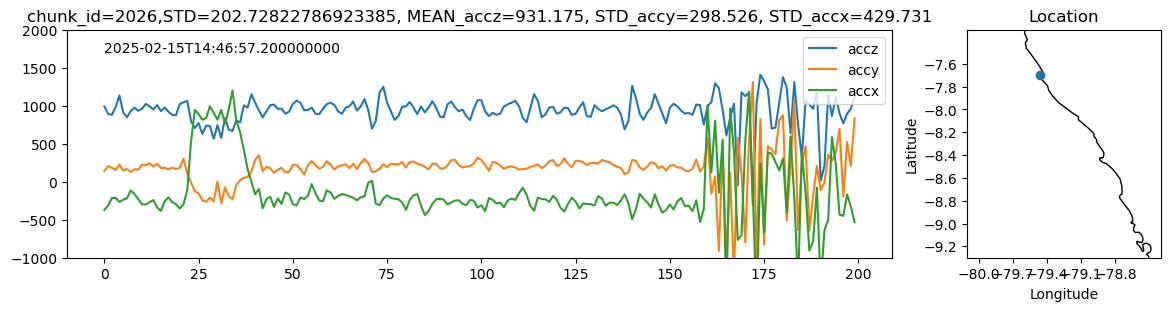

In [216]:
for i in data_40s_df["chunk_id"].unique():
    fig = plt.figure(figsize=(12,3),constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
    axs1 = fig.add_subplot(gs[0])
    axs2 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accz'].values,label='accz')
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accy'].values,label='accy')
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accx'].values,label='accx')
    axs1.set_ylim(-1000,2000)
    axs1.set_title(f'chunk_id={i},STD={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values)}, MEAN_accz={np.mean(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values):.3f}, STD_accy={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accy"].values):.3f}, STD_accx={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accx"].values):.3f}')
    axs1.text(0,1700, f'{data_40s_df[data_40s_df["chunk_id"]==i]["original_time"].values[0]}')
    axs1.legend(loc='upper right')

    # axs2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
    axs2.plot(data_40s_df[data_40s_df["chunk_id"]==i]['lon'].iloc[0], data_40s_df[data_40s_df["chunk_id"]==i]['lat'].iloc[0], 'o')
    axs2.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
    axs2.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
    axs2.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
    axs2.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
    # ax2.set_xticks(np.arange(-124.7, -124, 0.3), crs=ccrs.PlateCarree())
    # ax2.set_yticks(np.arange(46, 47, 0.2), crs=ccrs.PlateCarree())
    axs2.coastlines()
    axs2.set_title('Location')
    axs2.set_xlabel('Longitude')
    axs2.set_ylabel('Latitude')
    
    plt.savefig(f'chunk_40s_225662/chunk_{i}.png')
    plt.close()

In [219]:
# get standard deviation of accz for each chunk
time_accz = pd.DataFrame(columns=["time_accz","std_accz"])
for i in data_40s_df["chunk_id"].unique():
    std_accz=np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values)
    time_accz = pd.concat([time_accz, pd.DataFrame({"time_accz": [data_40s_df[data_40s_df["chunk_id"]==i]['original_time'].iloc[0]],
                                                    "std_accz":std_accz})], ignore_index=True)
time_accz

,time_accz,std_accz
0,2025-02-11 12:29:09.200,317.050809
1,2025-02-11 13:11:36.200,52.301189
2,2025-02-11 13:16:33.200,40.849077
3,2025-02-11 17:04:14.200,154.621334
4,2025-02-11 17:05:20.200,242.458230
...,...,...
1971,2025-04-27 12:33:14.200,386.672204
1972,2025-04-27 12:37:43.200,557.585462
1973,2025-04-27 12:45:16.200,174.450930
1974,2025-04-27 12:47:15.200,413.463856


In [ ]:
# Group time_accz by date and count number of records in each group with std_accz < 400 (good data)
time_accz['date'] = time_accz['time_accz'].dt.date
filtered_time_accz = time_accz[time_accz['std_accz'] < 400]
grouped_time_accz = filtered_time_accz.groupby('date').size()
grouped_time_accz_total = time_accz.groupby('date').size()
grouped_time_accz_df = grouped_time_accz.reset_index(name='good data')
grouped_time_accz_df['total'] = grouped_time_accz_total.values
print(grouped_time_accz_df)
# print(grouped_time_accz)
plt.bar(grouped_time_accz_df['date'], grouped_time_accz_df['total'], alpha=0.5, label='Total')
plt.bar(grouped_time_accz_df['date'], grouped_time_accz_df['good data'], label='STD_accz < 400')
plt.xticks(rotation=45)
plt.legend()
# plt.show()

ValueError: Length of values (72) does not match length of index (71)

: 

## plot all the chunks longer than 40s, adding a map for the locations

In [26]:
# Load bathymetry data
wrk_dir_ms2 = '/home/server/pi/homes/liux8/work/GETM/scripts_ms2/waves_analysis/'
bath1 = xr.open_dataset(wrk_dir_ms2 + 'GEBCO_2021_sub_ice_topo.nc')

# Filter the bathymetry data to the region within [x_geobox, y_geobox]
bath1_region = bath1.sel(lon=slice(x_geobox[0], x_geobox[1]), lat=slice(y_geobox[0], y_geobox[1]))
bath1_region
lon_bath = bath1_region.lon.values
lat_bath = bath1_region.lat.values
depth_bath = bath1_region.elevation.values

In [ ]:
# Filter the data for the specific date
# just for 2025-02-18
filtered_chunks = data_40s_df[data_40s_df['original_time'].dt.date == datetime.date(2025, 2, 18)]

# Get the unique chunk IDs for the filtered data
unique_chunks = filtered_chunks['chunk_id'].unique()

# Plot the chunks
for chunk_id in unique_chunks:
    chunk_data = filtered_chunks[filtered_chunks['chunk_id'] == chunk_id]
    if np.std(chunk_data['accz'])<400: # only plot the data with std < 400 (good data)
        plt.figure(figsize=(12, 4))
        # fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        fig = plt.figure(figsize=(14, 4), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
        ax1 = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
        # Plot the acceleration data
        ax1.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
        ax1.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
        ax1.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')
        ax1.set_title(f"Chunk ID: {chunk_id} on 2025-02-18, std= {np.std(chunk_data['accz'])}")
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Acceleration')
        ax1.set_ylim(-1000, 2000)
        ax1.legend()
        
        # Plot the position on the map
        # ax_map = axs[1]
        # Add topography contour
        ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
        plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
        ax_map.plot(chunk_data['lon'].iloc[0], chunk_data['lat'].iloc[0], 'ro')
        ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
        ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
        ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
        ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
        ax_map.coastlines()
        ax_map.set_title('Location')
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        # plt.show()
        plt.savefig(f'chunk_plots/chunk_2025-02-18_{chunk_id}.png')
        plt.close()
    else: # save the chunks with std>400 (bad data)
        plt.figure(figsize=(12, 4))
        # fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        fig = plt.figure(figsize=(14, 4), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
        ax1 = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
        # Plot the acceleration data
        ax1.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
        ax1.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
        ax1.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')
        ax1.set_title(f"Chunk ID: {chunk_id} on 2025-02-18, std= {np.std(chunk_data['accz'])}")
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Acceleration')
        ax1.set_ylim(-1000, 2000)
        ax1.legend()
        
        # Plot the position on the map
        # ax_map = axs[1]
        # Add topography contour
        ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
        plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
        ax_map.plot(chunk_data['lon'].iloc[0], chunk_data['lat'].iloc[0], 'ro')
        ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
        ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
        ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
        ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
        ax_map.coastlines()
        ax_map.set_title('Location')
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        # plt.show()
        plt.savefig(f'chunk_plots_2/chunk_2025-02-18_{chunk_id}.png')
        plt.close()
        # break

/tmp/ipykernel_3476401/3899120097.py:47: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(14, 4), constrained_layout=True)
/tmp/ipykernel_3476401/3899120097.py:45: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 4))


<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

...

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

Chunk ID: 7803
Number of records: 530
Bird ID: 225662.0
Location: Lon=-79.47127532958984, Lat=-7.801984786987305
Timestamp: 2025-04-24 18:50:01.200000

First 5 rows of data:
        mask_ik    accz   bird_id                 lon                 lat  \
434895   1224.0  1096.0  225662.0  -79.47127532958984  -7.801984786987305   
434896   1224.0  1332.0  225662.0  -79.47127532958984  -7.801984786987305   
434897   1224.0   911.0  225662.0  -79.47127532958984  -7.801984786987305   
434898   1224.0   734.0  225662.0  -79.47127532958984  -7.801984786987305   
434899   1224.0  1119.0  225662.0  -79.47127532958984  -7.801984786987305   

                 original_time chunk_id   accy   accx  
434895 2025-04-24 18:50:01.200     7803 -678.0 -449.0  
434896 2025-04-24 18:50:01.400     7803  686.0  397.0  
434897 2025-04-24 18:50:01.600     7803 -820.0 -417.0  
434898 2025-04-24 18:50:01.800     7803  626.0 -279.0  
434899 2025-04-24 18:50:02.000     7803 -281.0 -657.0  
Chunk ID: 7809
Number of re

/tmp/ipykernel_16398/678747339.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12,3),constrained_layout=True)


Chunk ID: 7971
Number of records: 600
Bird ID: 225662.0
Location: Lon=-79.58081054687501, Lat=-7.635476589202881
Timestamp: 2025-04-27 12:47:15.200000

First 5 rows of data:
        mask_ik    accz   bird_id                 lon                 lat  \
458020   1248.0  1220.0  225662.0  -79.58081054687501  -7.635476589202881   
458021   1248.0  1037.0  225662.0  -79.58081054687501  -7.635476589202881   
458022   1248.0   879.0  225662.0  -79.58081054687501  -7.635476589202881   
458023   1248.0  1035.0  225662.0  -79.58081054687501  -7.635476589202881   
458024   1248.0  1359.0  225662.0  -79.58081054687501  -7.635476589202881   

                 original_time chunk_id   accy    accx  
458020 2025-04-27 12:47:15.200     7971  139.0    -1.0  
458021 2025-04-27 12:47:15.400     7971  262.0   245.0  
458022 2025-04-27 12:47:15.600     7971   87.0  -357.0  
458023 2025-04-27 12:47:15.800     7971 -265.0  -251.0  
458024 2025-04-27 12:47:16.000     7971  -58.0 -1041.0  


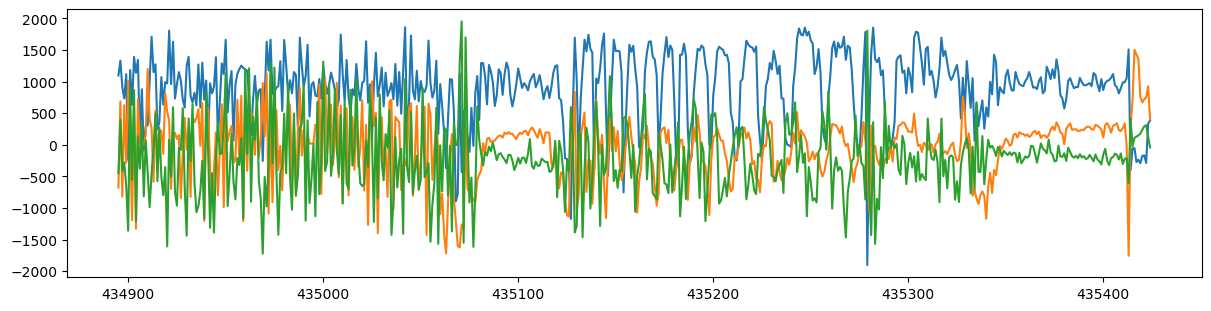

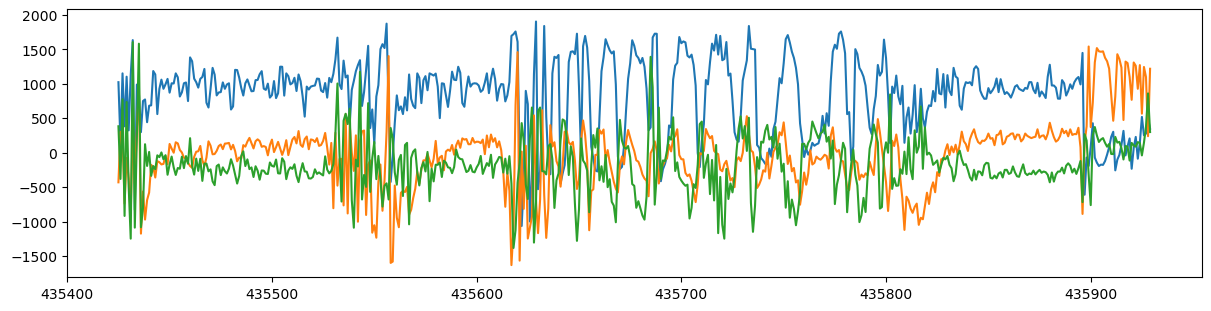

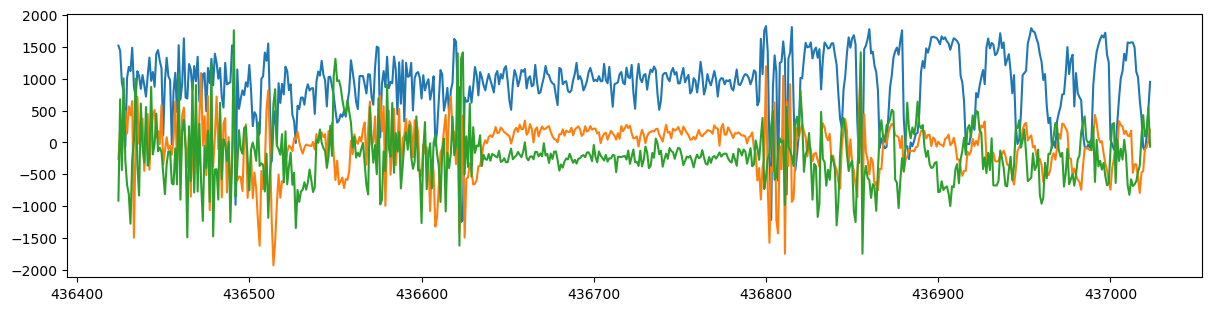

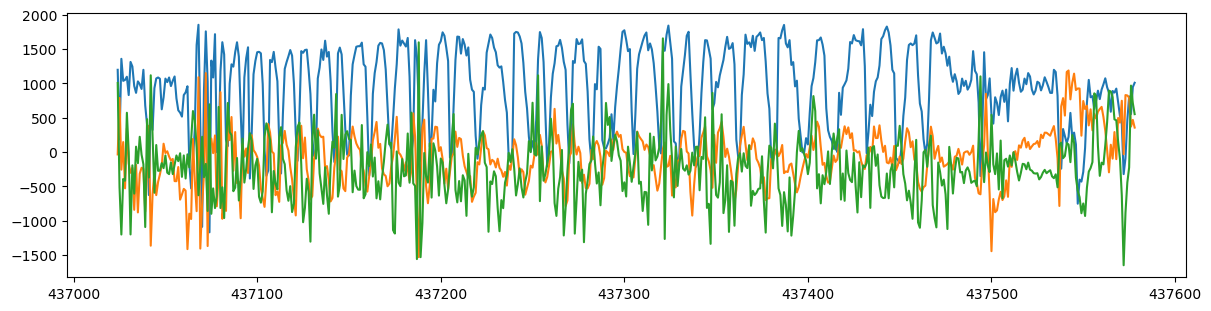

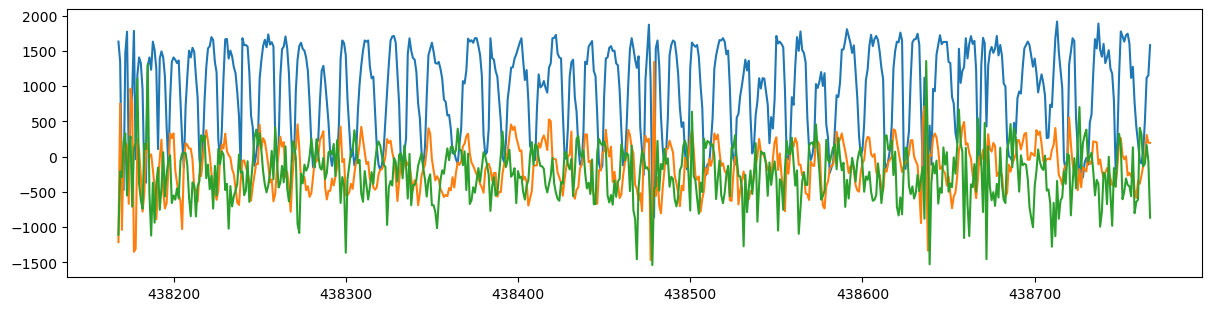

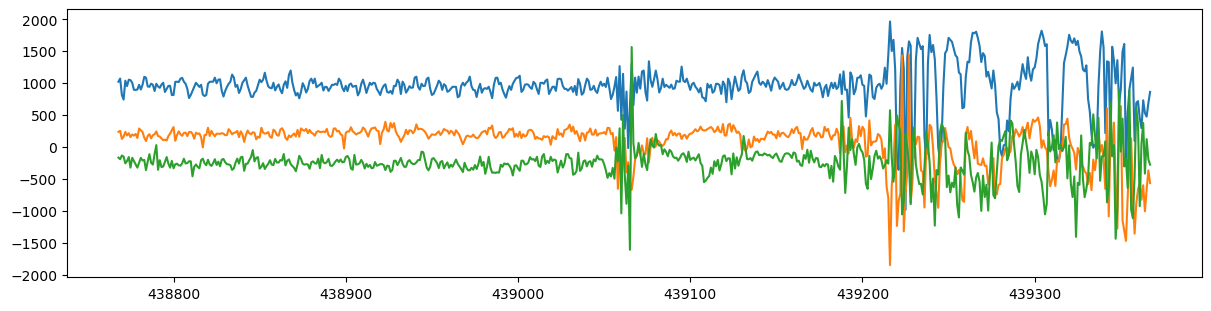

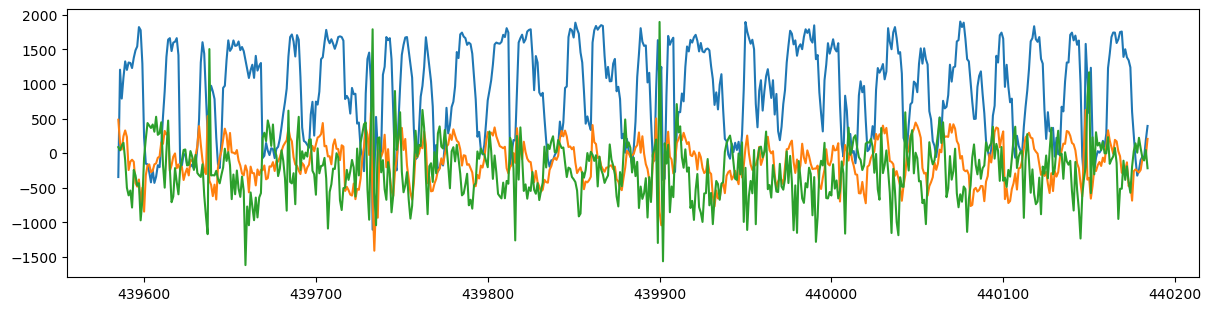

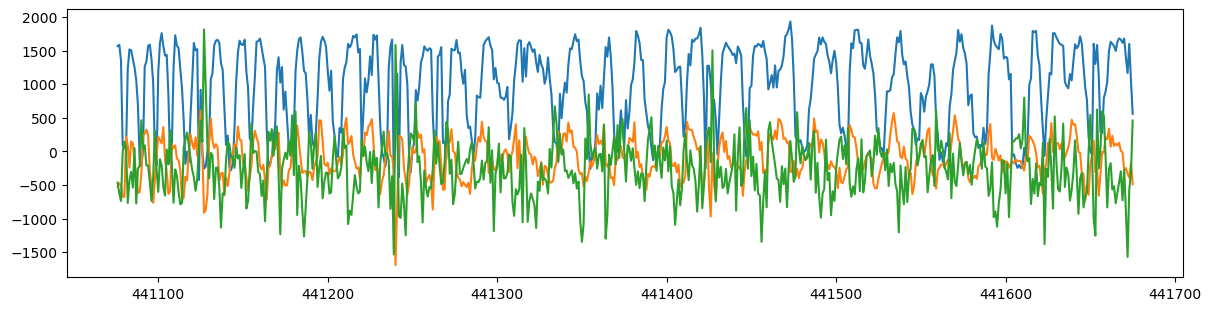

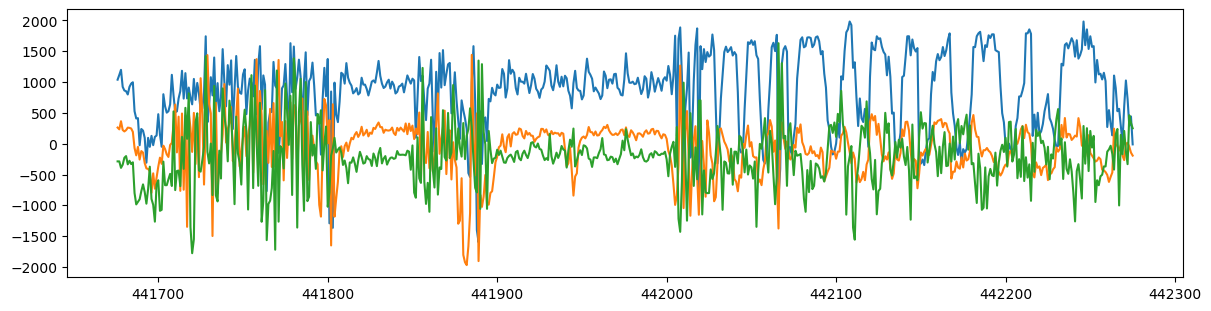

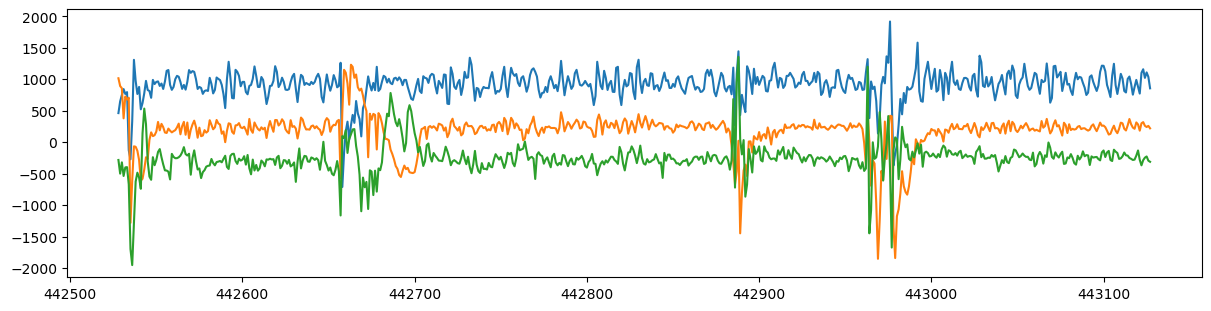

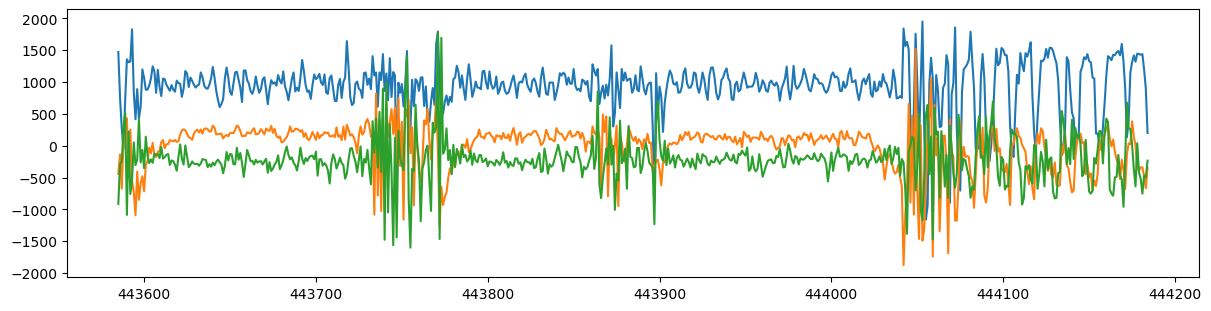

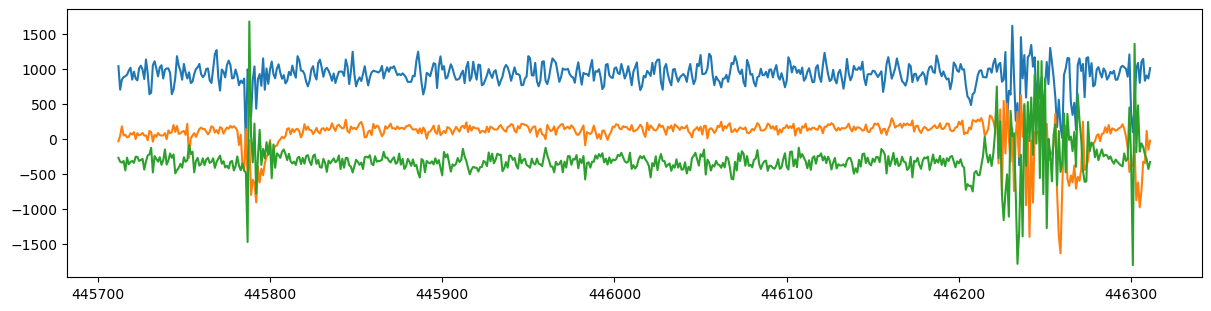

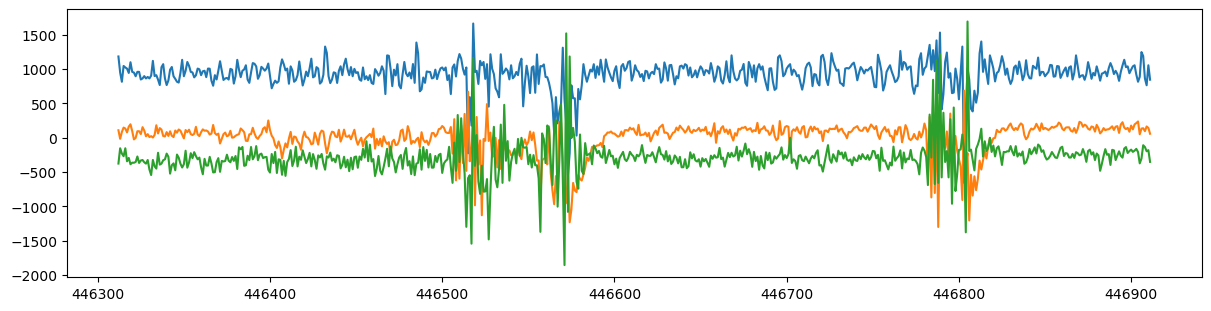

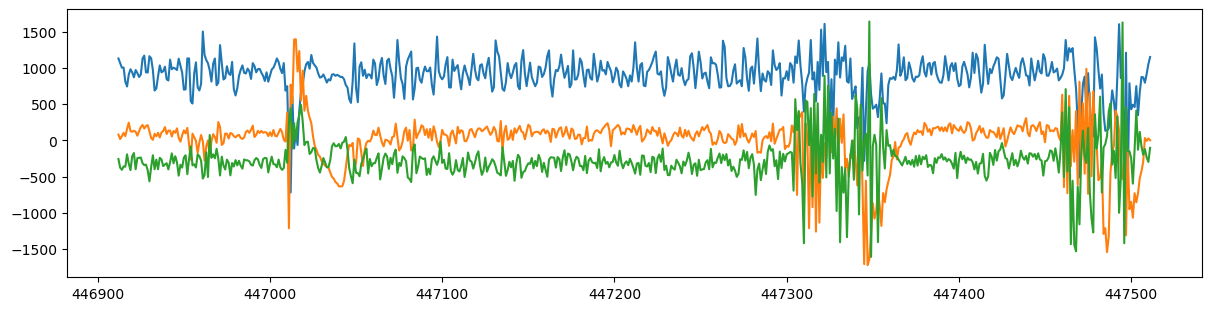

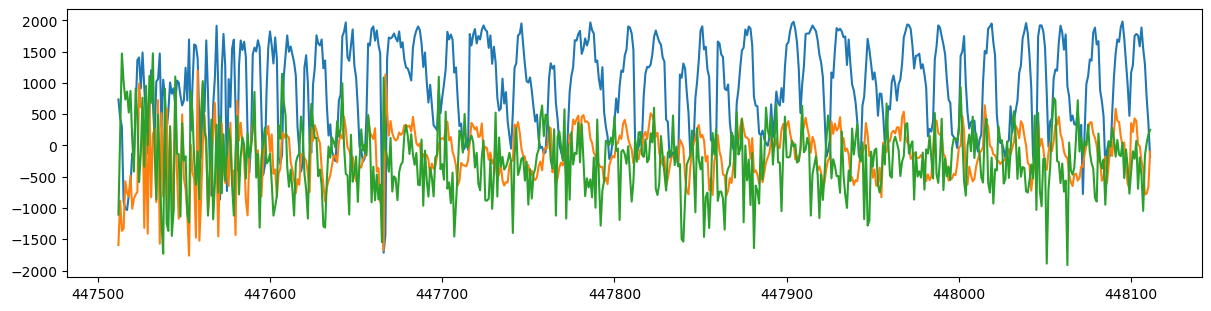

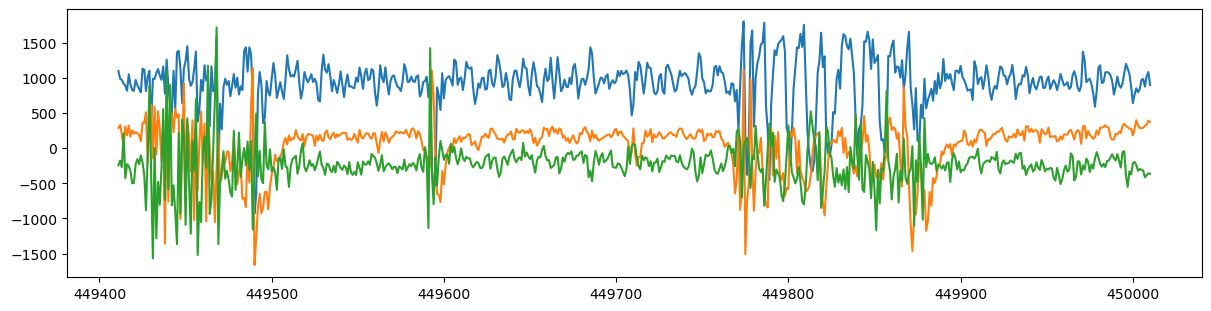

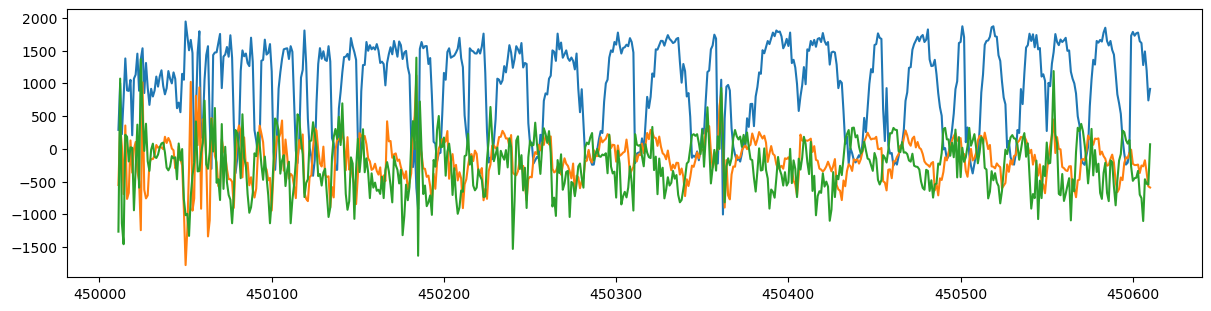

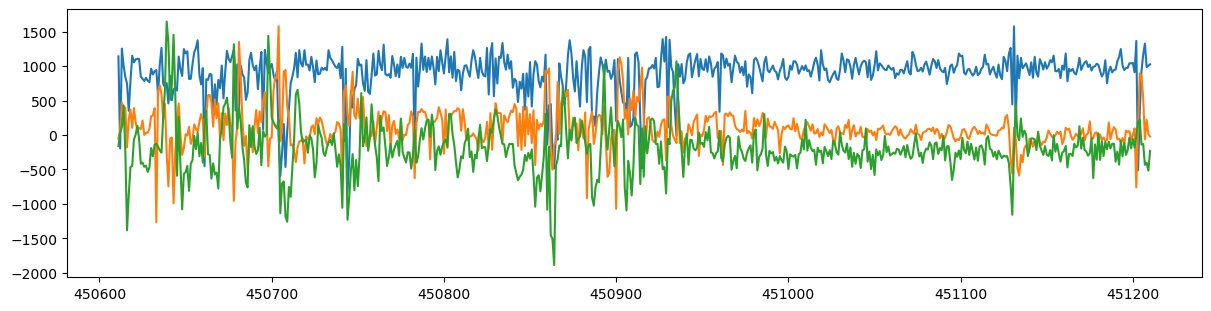

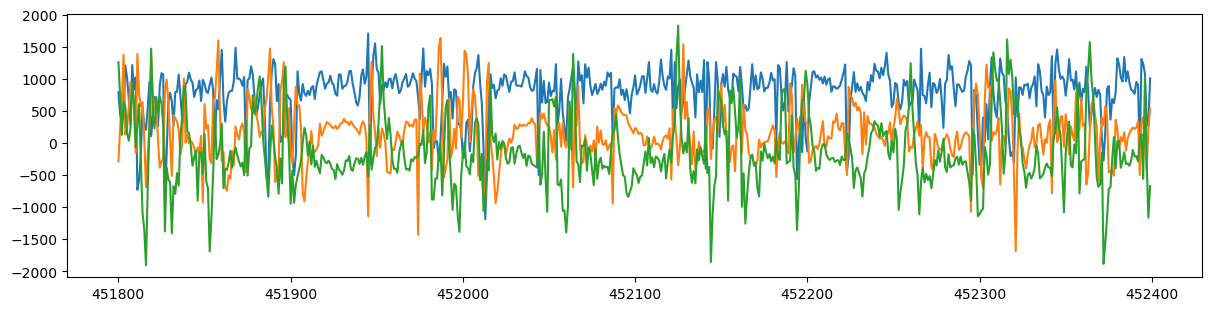

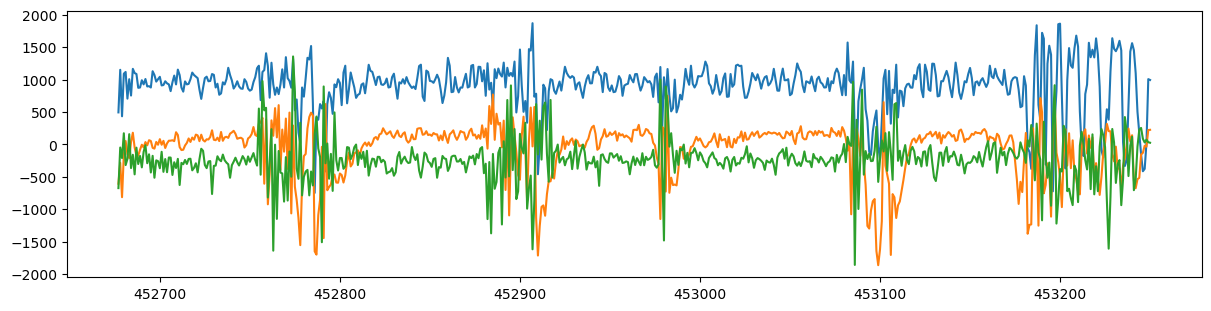

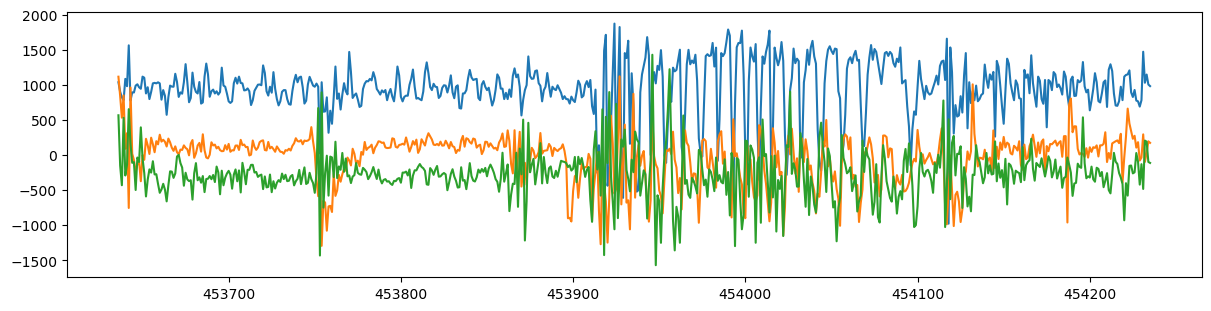

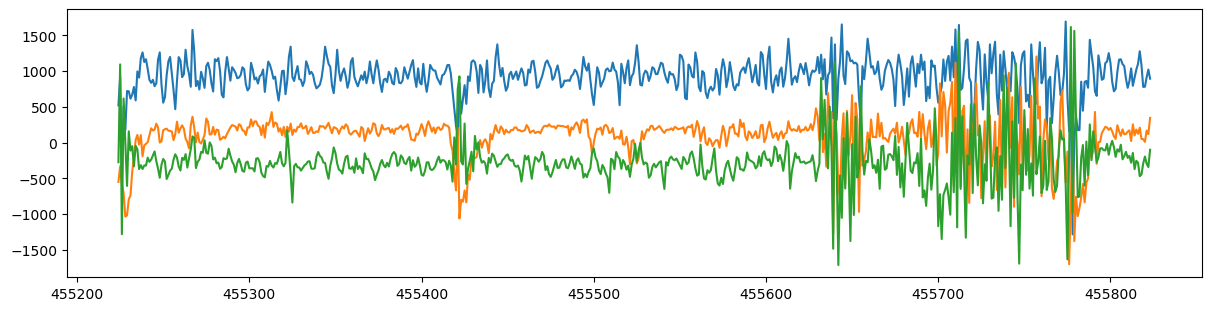

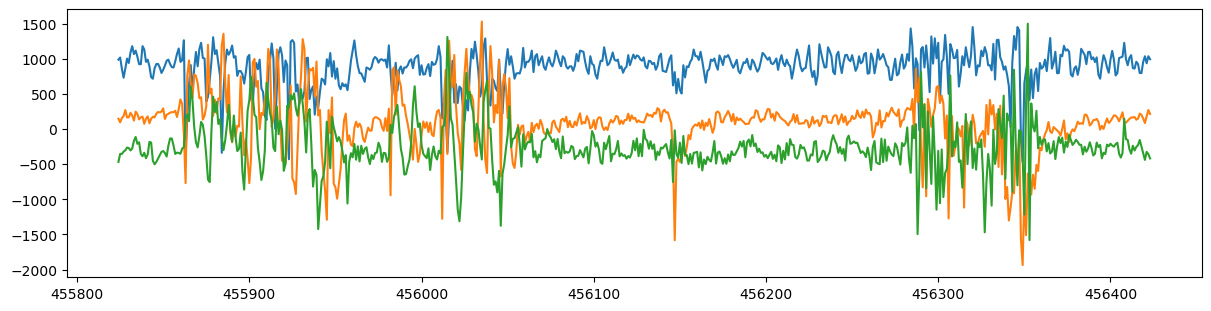

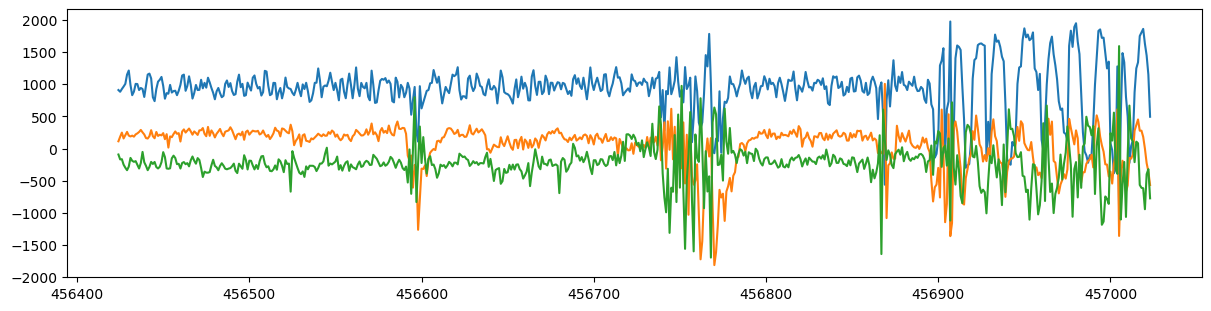

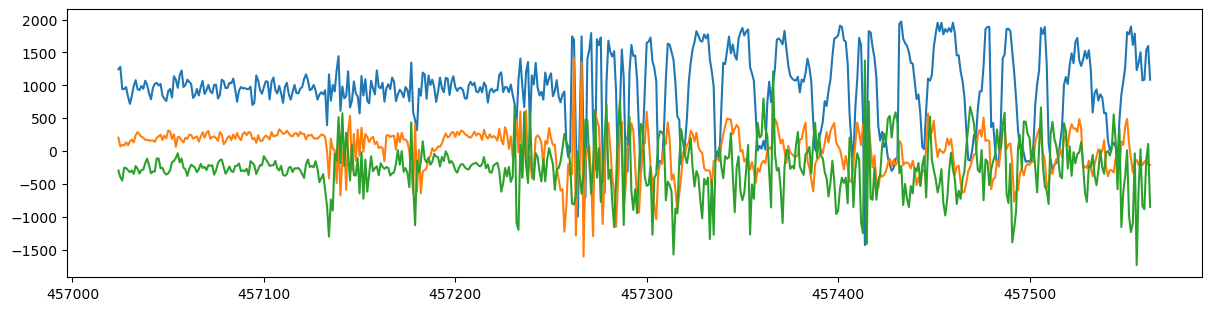

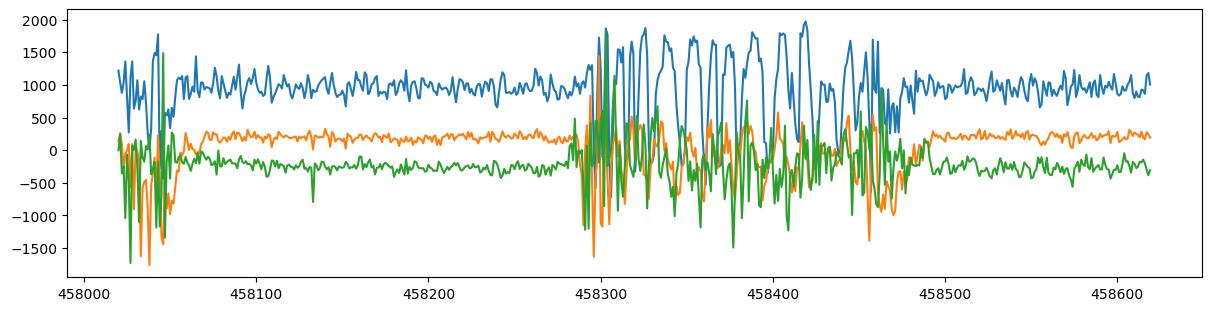

In [243]:
for ik in data_40s_df.chunk_id.unique():
    # print(ik)
    # Display the rows for the first chunk_id in the dataframe
    chunk_data = data_40s_df[data_40s_df["chunk_id"]==ik]
    
    # Display basic info about the chunk
    if len(chunk_data) > 500:

        print(f"Chunk ID: {ik}")
        print(f"Number of records: {len(chunk_data)}")
        print(f"Bird ID: {chunk_data['bird_id'].iloc[0]}")
        print(f"Location: Lon={chunk_data['lon'].iloc[0]}, Lat={chunk_data['lat'].iloc[0]}")
        print(f"Timestamp: {chunk_data['original_time'].iloc[0]}")
        
        # Display the first few rows of the chunk data
        print("\nFirst 5 rows of data:")
        print(chunk_data.head())
        fig = plt.figure(figsize=(12,3),constrained_layout=True)
        plt.plot(chunk_data['accz'])
        plt.plot(chunk_data['accy'])
        plt.plot(chunk_data['accx'])


# load reanalysis data

In [220]:
ds_reana = xr.open_dataset('reanalysis-era5-single-levels-timeseries-wavb_3lp_v_.nc')
ds_reana
ds_period = xr.open_dataset('reanalysis-era5-single-levels-timeseries-wavtcmbbimk.nc')
ds_period

<xarray.Dataset>
Dimensions:     (valid_time: 2616)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2025-01-01 ... 2025-04-19T23:00:00
Data variables:
    mwp         (valid_time) float32 ...
    latitude    float64 ...
    longitude   float64 ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-05T05:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [222]:
acc_reana = ds_reana.swh.values/(ds_period.mwp.isel(valid_time=slice(0,2592)).values)**2*(np.pi)**2
acc_reana

array([0.13874564, 0.13753864, 0.1361277 , ..., 0.19456105, 0.203726  ,
       0.2150434 ], dtype=float32)

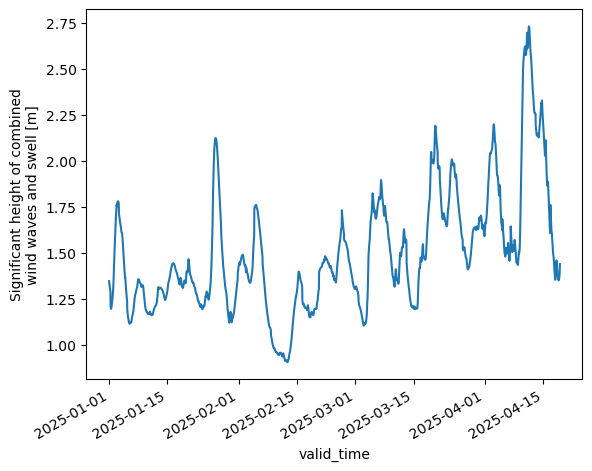

In [51]:
ds_reana.swh.plot()

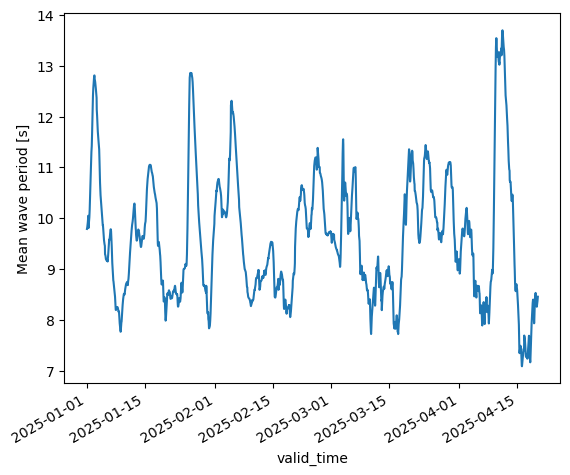

In [103]:
ds_period.mwp.plot()

# GET the statistic

## filter

In [119]:
from scipy.signal import butter, filtfilt

def power_spectral_density(accz_values, accz_rolling_5s):
    from scipy.signal import welch
    f_accz, Pxx_accz = welch(accz_values, fs=5, nperseg=256)
    f_accz_rolling, Pxx_accz_rolling = welch(accz_rolling_5s, fs=5, nperseg=256)
    return f_accz, Pxx_accz, f_accz_rolling, Pxx_accz_rolling

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

0.9619051107681762
0.33561815641601916


/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 200, using nperseg = 200
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


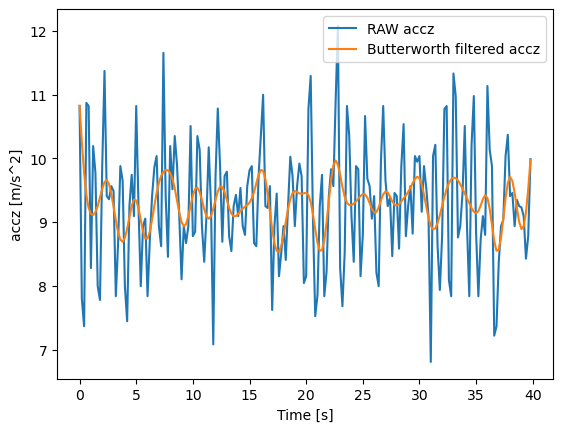

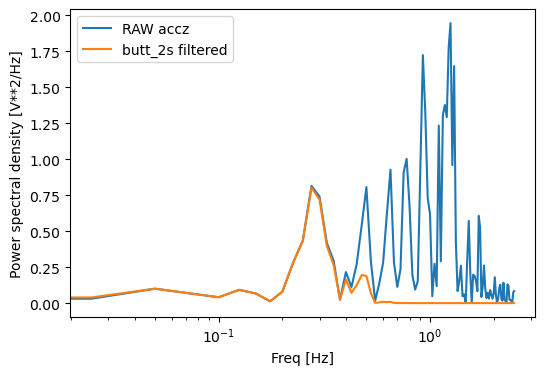

In [223]:
accz_1 = data_40s_df[data_40s_df["chunk_id"]==2008]["accz"].values/1000*9.81

plt.plot(np.arange(200)/5,accz_1,label = 'RAW accz')

sample_rate = 5
order=4
accz_1_filtered_1s = butter_lowpass_filter(accz_1, 1/2, sample_rate, order)

plt.plot(np.arange(200)/5,accz_1_filtered_1s,label = 'Butterworth filtered accz')
plt.xlabel('Time [s]')
plt.ylabel('accz [m/s^2]')
plt.legend()

f_accz, Pxx_accz, f_accz_butt_1s, Pxx_accz_butt_1s = power_spectral_density(accz_1, accz_1_filtered_1s)

fig = plt.figure(figsize=(6, 4))
plt.plot(f_accz, Pxx_accz,label='RAW accz')
plt.plot(f_accz_butt_1s, Pxx_accz_butt_1s,label='butt_2s filtered')
plt.xscale('log')
plt.xlabel('Freq [Hz]')
plt.ylabel('Power spectral density [V**2/Hz]')
plt.legend()

print(np.std(accz_1))   
print(np.std(accz_1_filtered_1s))

1.204498773602514
0.4677750865714025


/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


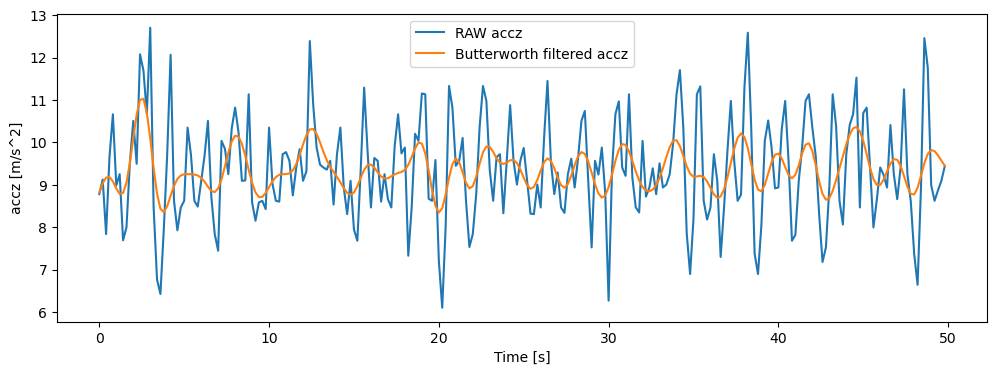

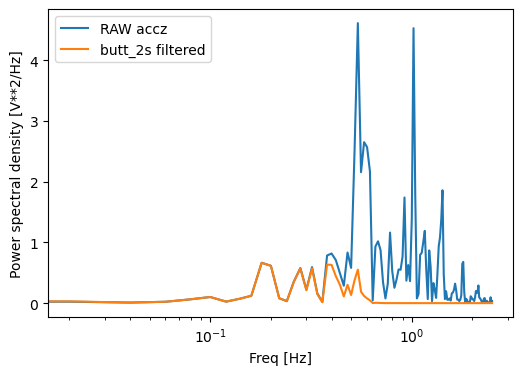

In [214]:
accz_1 = data_40s_df[data_40s_df["chunk_id"]==7688]["accz"].values/1000*9.81

fig = plt.figure(figsize=(12, 4))
plt.plot(np.arange(250)/5,accz_1,label = 'RAW accz')

sample_rate = 5
order=4
accz_1_filtered_1s = butter_lowpass_filter(accz_1, 1/2, sample_rate, order)

plt.plot(np.arange(250)/5,accz_1_filtered_1s,label = 'Butterworth filtered accz')
plt.xlabel('Time [s]')
plt.ylabel('accz [m/s^2]')
plt.legend()

f_accz, Pxx_accz, f_accz_butt_1s, Pxx_accz_butt_1s = power_spectral_density(accz_1, accz_1_filtered_1s)

fig = plt.figure(figsize=(6, 4))
plt.plot(f_accz, Pxx_accz,label='RAW accz')
plt.plot(f_accz_butt_1s, Pxx_accz_butt_1s,label='butt_2s filtered')
plt.xscale('log')
plt.xlabel('Freq [Hz]')
plt.ylabel('Power spectral density [V**2/Hz]')
plt.legend()

print(np.std(accz_1))   
print(np.std(accz_1_filtered_1s))

In [182]:
std_accz = np.zeros(len(data_40s_df["chunk_id"].unique()))
time_accz = np.zeros(len(data_40s_df["chunk_id"].unique())).astype('datetime64[ns]')
std_accz_butt_1s = np.zeros(len(data_40s_df["chunk_id"].unique()))
icount=0
for i in data_40s_df["chunk_id"].unique():
    
    accz00 = data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values
    if (np.max(accz00)<1500)&(np.min(accz00)>500):
        std_accz[icount]=np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values)
        time_accz[icount]=data_40s_df[data_40s_df["chunk_id"]==i]['original_time'].iloc[0]
        accz00_filtered_1s = butter_lowpass_filter(accz00, 1/2, sample_rate, order)
        std_accz_butt_1s[icount] = np.std(accz00_filtered_1s)
    else:
        std_accz[icount]=np.nan
        time_accz[icount]=data_40s_df[data_40s_df["chunk_id"]==i]['original_time'].iloc[0]
        std_accz_butt_1s[icount] = np.nan
    icount=icount+1

In [53]:
print(f'Total number of chunks longer than 40s is {len(data_40s_df["chunk_id"].unique())}')
num_elements_less_than_500 = np.sum(std_accz < 400)
print(f'Number of chunks whose STD smaller than 400 is {num_elements_less_than_500}')

Total number of chunks longer than 40s is 1899
Number of chunks whose STD smaller than 400 is 1164


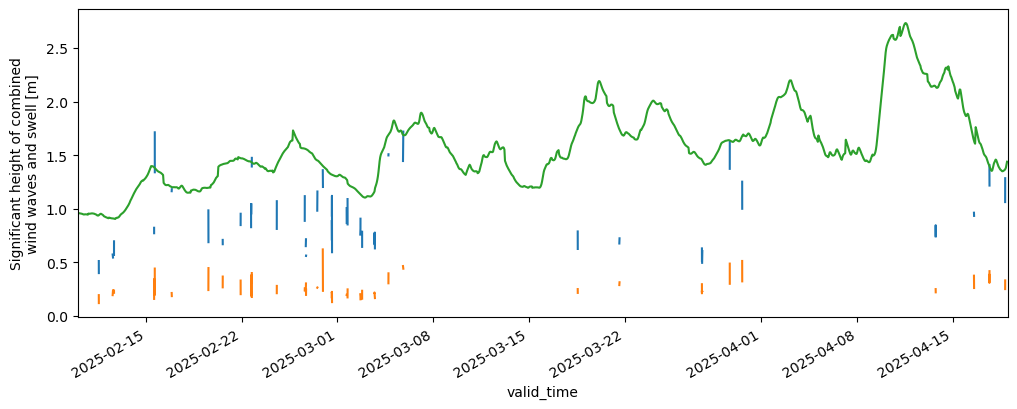

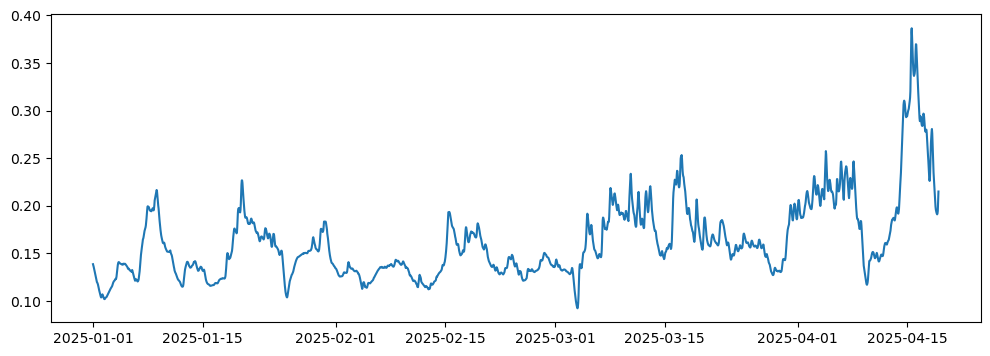

In [179]:
std_accz_2 = std_accz[std_accz<300]
time_accz_2 = time_accz[std_accz<300]
plt.figure(figsize=(12, 4))
# plt.plot(time_accz_2,std_accz_2/1000*9.81)
plt.plot(time_accz,std_accz/1000*9.81)
plt.plot(time_accz,std_accz_butt_1s/1000*9.81)
ds_reana.swh.plot()
plt.xlim(pd.to_datetime('2025-02-10'),pd.to_datetime('2025-04-19'))

plt.figure(figsize=(12, 4))

plt.plot(ds_reana.valid_time.values,acc_reana)

In [81]:
ds_reana

<xarray.Dataset>
Dimensions:     (valid_time: 2592)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2025-01-01 ... 2025-04-18T23:00:00
Data variables:
    swh         (valid_time) float32 1.347 1.339 1.331 ... 1.383 1.409 1.44
    latitude    float64 -8.0
    longitude   float64 -81.0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-05T05:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

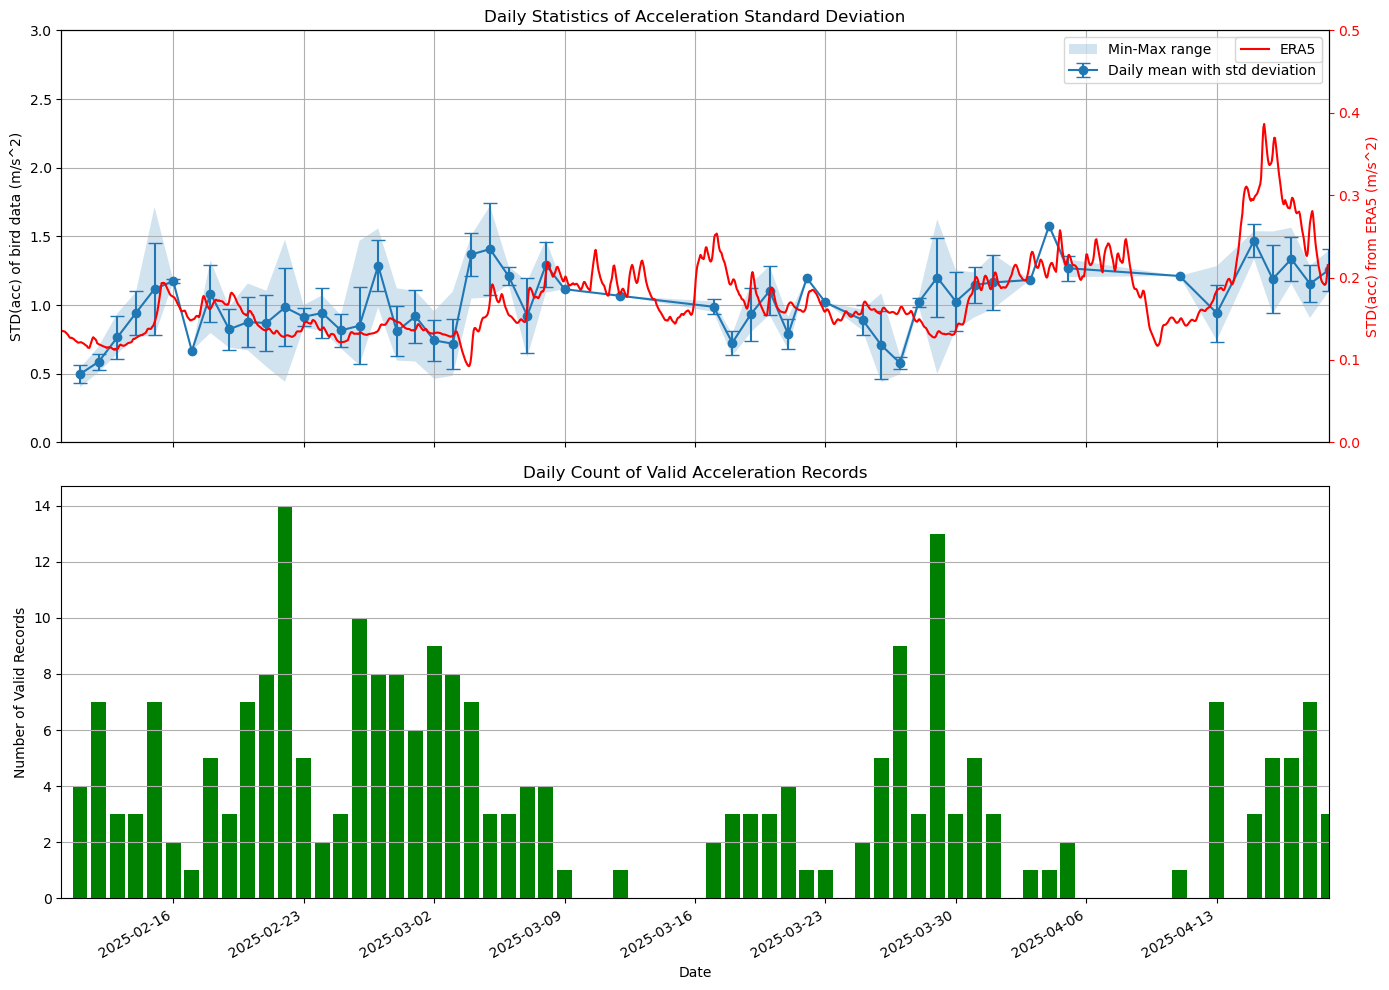

In [185]:
# Group std_accz by date and create a timeseries analysis
import matplotlib.dates as mdates

# Create a DataFrame with time_accz and std_accz
std_accz_df = pd.DataFrame({
    'time': pd.to_datetime(time_accz),
    'std_accz': std_accz
})

# Drop NaN values
std_accz_df = std_accz_df.dropna()

# Convert std_accz from raw values to m/s^2
std_accz_df['std_accz_ms2'] = std_accz_df['std_accz'] / 1000 * 9.81

# Group by date
std_accz_df['date'] = std_accz_df['time'].dt.date
daily_stats = std_accz_df.groupby('date').agg({
    'std_accz_ms2': ['mean', 'std', 'count', 'min', 'max']
}).reset_index()

# Flatten the multi-level columns
daily_stats.columns = ['_'.join(col).strip('_') for col in daily_stats.columns.values]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot the daily mean and standard deviation
ax1.errorbar(daily_stats['date'], daily_stats['std_accz_ms2_mean'], 
            yerr=daily_stats['std_accz_ms2_std'],
            fmt='o-', capsize=5, label='Daily mean with std deviation')

ax1.fill_between(daily_stats['date'], 
                daily_stats['std_accz_ms2_min'],
                daily_stats['std_accz_ms2_max'],
                alpha=0.2, label='Min-Max range')
ax1.set_ylabel('STD(acc) of bird data (m/s^2)')
ax1.set_title('Daily Statistics of Acceleration Standard Deviation')
ax1.set_ylim(0, 3)
ax1.legend()
ax1.grid(True)

# Plot the number of valid records per day
ax2.bar(daily_stats['date'], daily_stats['std_accz_ms2_count'], color='green')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Valid Records')
ax2.set_title('Daily Count of Valid Acceleration Records')
ax2.grid(True, axis='y')

# Format x-axis for better readability
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
fig.autofmt_xdate()

# Overlay ERA5 reanalysis SWH data if possible
if 'ds_reana' in globals() and 'swh' in ds_reana:
    ax3 = ax1.twinx()
    # Convert date range to match ds_reana time coordinate format
    date_range = pd.date_range(start=std_accz_df['date'].min(), end=std_accz_df['date'].max())
    # print(date_range)
    ds_reana_subset = ds_reana.sel(valid_time=slice(date_range[0], date_range[-1]))
    # ax3.plot(ds_reana_subset.valid_time, ds_reana_subset.swh, 'r-', label='ERA5 SWH')
    ax3.plot(ds_reana.valid_time, acc_reana, 'r-', label='ERA5')
    # ax3.set_ylabel('Significant Wave Height (m)', color='r')
    ax3.set_ylabel('STD(acc) from ERA5 (m/s^2)', color='r')
    ax3.tick_params(axis='y', colors='r')
    ax3.set_xlim(pd.to_datetime('2025-02-10'), pd.to_datetime('2025-04-19'))
    ax3.legend(loc='upper right')
    ax3.set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

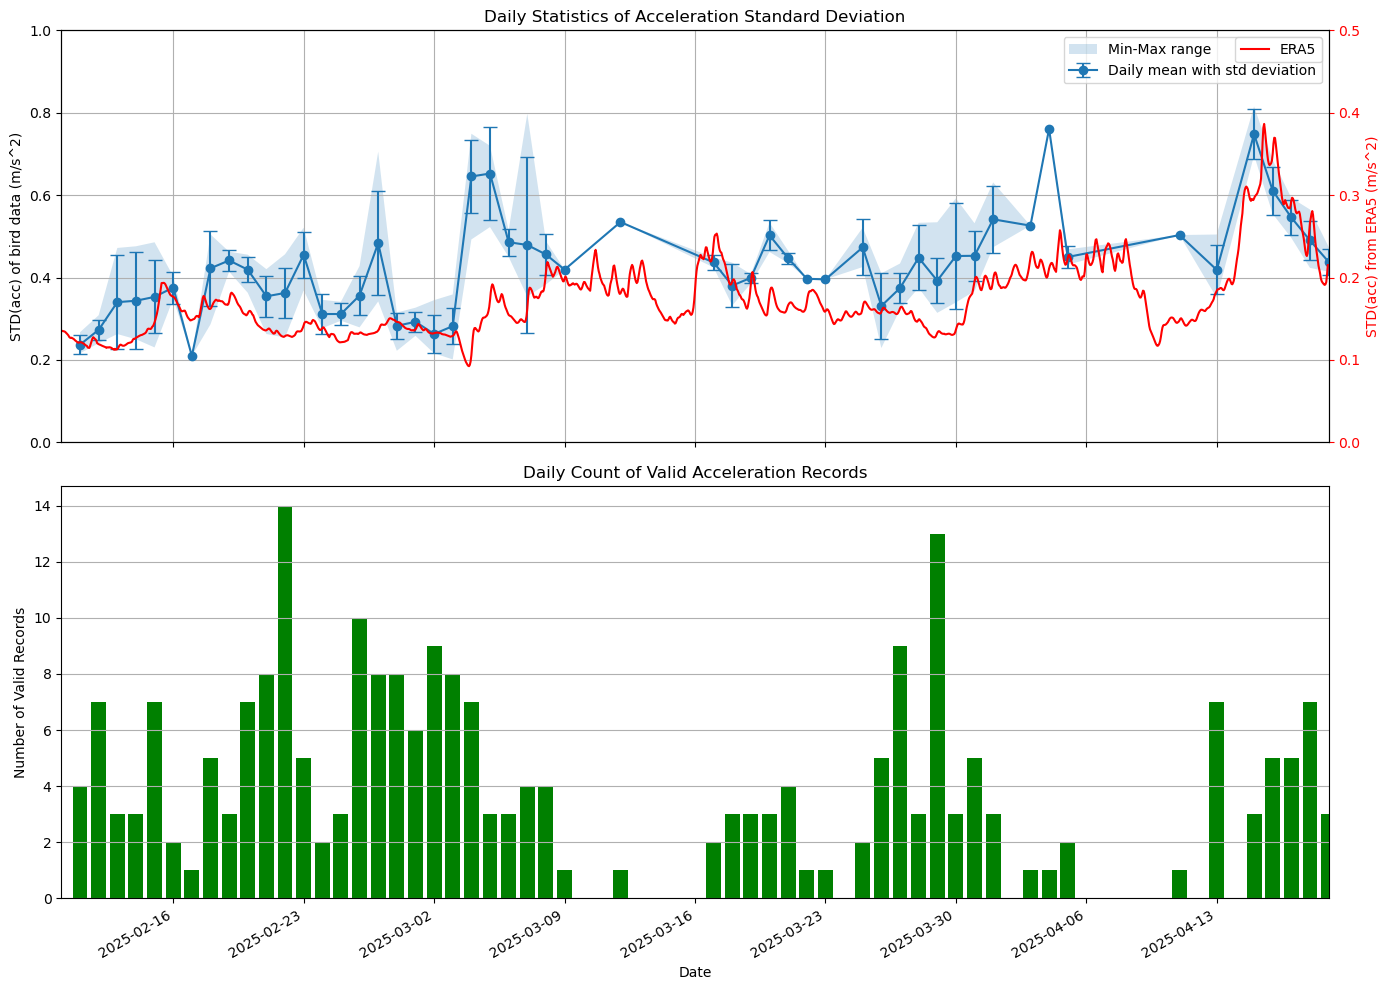

In [183]:
# Group std_accz by date and create a timeseries analysis
import matplotlib.dates as mdates

# Create a DataFrame with time_accz and std_accz
std_accz_df = pd.DataFrame({
    'time': pd.to_datetime(time_accz),
    'std_accz': std_accz_butt_1s
})

# Drop NaN values
std_accz_df = std_accz_df.dropna()

# Convert std_accz from raw values to m/s^2
std_accz_df['std_accz_ms2'] = std_accz_df['std_accz'] / 1000 * 9.81

# Group by date
std_accz_df['date'] = std_accz_df['time'].dt.date
daily_stats = std_accz_df.groupby('date').agg({
    'std_accz_ms2': ['mean', 'std', 'count', 'min', 'max']
}).reset_index()

# Flatten the multi-level columns
daily_stats.columns = ['_'.join(col).strip('_') for col in daily_stats.columns.values]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot the daily mean and standard deviation
ax1.errorbar(daily_stats['date'], daily_stats['std_accz_ms2_mean'], 
            yerr=daily_stats['std_accz_ms2_std'],
            fmt='o-', capsize=5, label='Daily mean with std deviation')

ax1.fill_between(daily_stats['date'], 
                daily_stats['std_accz_ms2_min'],
                daily_stats['std_accz_ms2_max'],
                alpha=0.2, label='Min-Max range')
ax1.set_ylabel('STD(acc) of bird data (m/s^2)')
ax1.set_title('Daily Statistics of Acceleration Standard Deviation')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True)

# Plot the number of valid records per day
ax2.bar(daily_stats['date'], daily_stats['std_accz_ms2_count'], color='green')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Valid Records')
ax2.set_title('Daily Count of Valid Acceleration Records')
ax2.grid(True, axis='y')

# Format x-axis for better readability
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
fig.autofmt_xdate()

# Overlay ERA5 reanalysis SWH data if possible
if 'ds_reana' in globals() and 'swh' in ds_reana:
    ax3 = ax1.twinx()
    # Convert date range to match ds_reana time coordinate format
    date_range = pd.date_range(start=std_accz_df['date'].min(), end=std_accz_df['date'].max())
    # print(date_range)
    ds_reana_subset = ds_reana.sel(valid_time=slice(date_range[0], date_range[-1]))
    # ax3.plot(ds_reana_subset.valid_time, ds_reana_subset.swh, 'r-', label='ERA5 SWH')
    ax3.plot(ds_reana.valid_time, acc_reana, 'r-', label='ERA5')
    # ax3.set_ylabel('Significant Wave Height (m)', color='r')
    ax3.set_ylabel('STD(acc) from ERA5 (m/s^2)', color='r')
    ax3.tick_params(axis='y', colors='r')
    ax3.set_xlim(pd.to_datetime('2025-02-10'), pd.to_datetime('2025-04-19'))
    ax3.legend(loc='upper right')
    ax3.set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

In [172]:
daily_stats['std_accz_ms2_mean']

0     0.880181
1     1.044679
2     1.746275
3     1.105748
4     0.647666
        ...   
62    1.146884
63    0.832298
64    2.006736
65    1.584990
66    0.878489
Name: std_accz_ms2_mean, Length: 67, dtype: float64

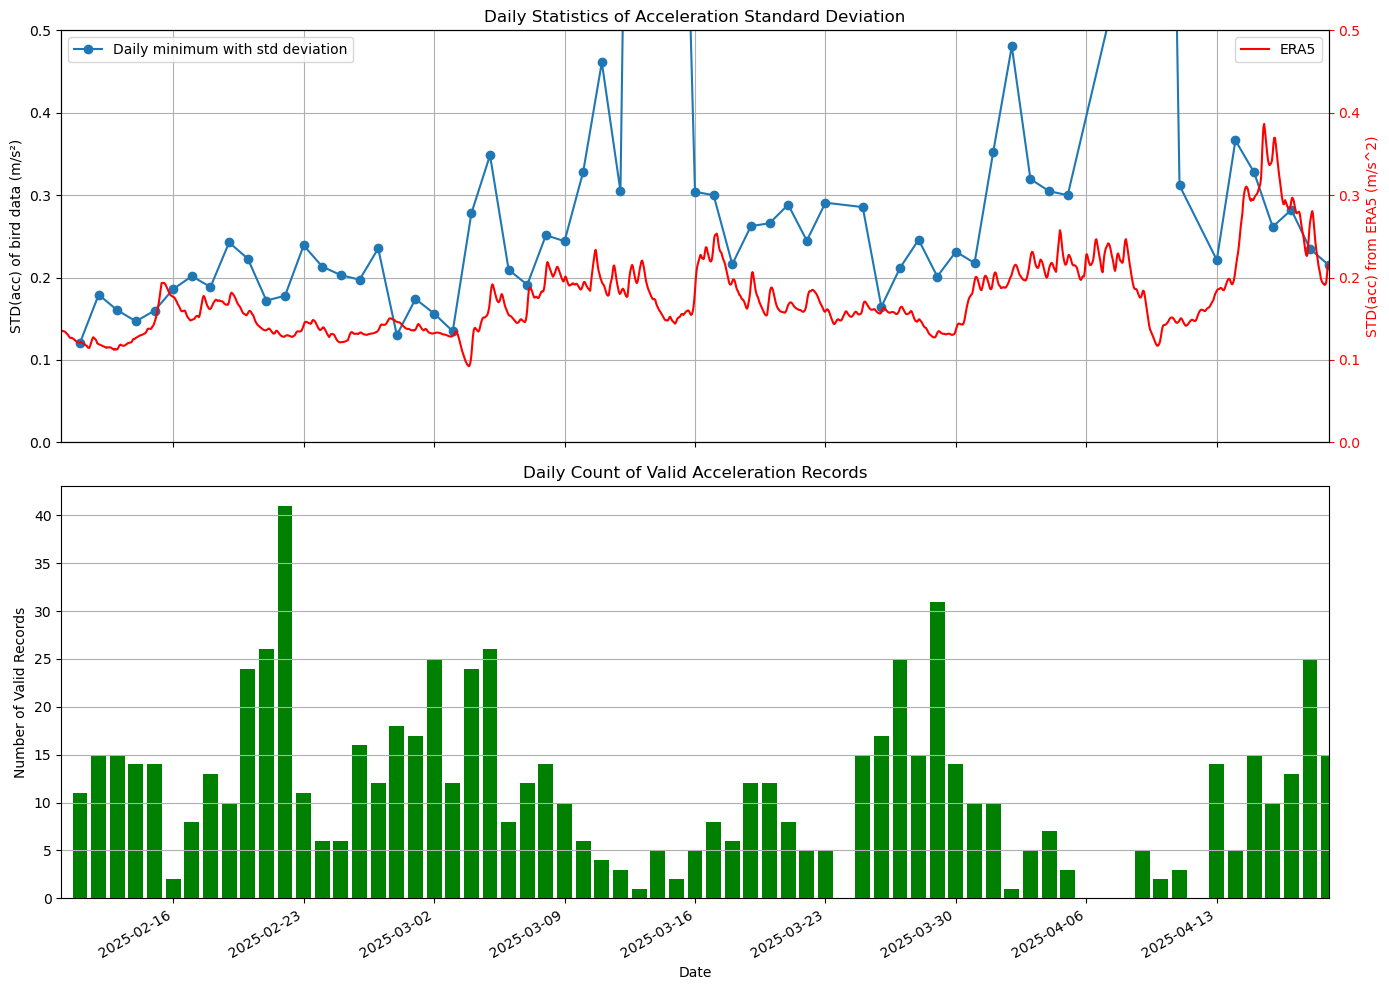

In [177]:
# Create a DataFrame with time_accz and std_accz
std_accz_df = pd.DataFrame({
    'time': pd.to_datetime(time_accz),
    'std_accz': std_accz_butt_1s
})

# Drop NaN values
std_accz_df = std_accz_df.dropna()

# Convert std_accz from raw values to m/s^2
std_accz_df['std_accz_ms2'] = std_accz_df['std_accz'] / 1000 * 9.81

# Group by date
std_accz_df['date'] = std_accz_df['time'].dt.date
daily_stats = std_accz_df.groupby('date').agg({
    'std_accz_ms2': ['mean', 'std', 'count', 'min', 'max']
}).reset_index()

# Flatten the multi-level columns
daily_stats.columns = ['_'.join(col).strip('_') for col in daily_stats.columns.values]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot the daily mean and standard deviation
# ax1.errorbar(daily_stats['date'], daily_stats['std_accz_ms2_min'], 
#             yerr=daily_stats['std_accz_ms2_std'],
#             fmt='o-', capsize=5, label='Daily mean with std deviation')

ax1.plot(daily_stats['date'], daily_stats['std_accz_ms2_min'], 
            # yerr=daily_stats['std_accz_ms2_std'],
            'o-',  label='Daily minimum with std deviation')
# ax1.fill_between(daily_stats['date'], 
#                 daily_stats['std_accz_ms2_min'],
#                 daily_stats['std_accz_ms2_max'],
#                 alpha=0.2, label='Min-Max range')
ax1.set_ylabel('STD(acc) of bird data (m/s²)')
ax1.set_title('Daily Statistics of Acceleration Standard Deviation')
ax1.set_ylim(0, 0.5)
ax1.legend()
ax1.grid(True)

# Plot the number of valid records per day
ax2.bar(daily_stats['date'], daily_stats['std_accz_ms2_count'], color='green')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Valid Records')
ax2.set_title('Daily Count of Valid Acceleration Records')
ax2.grid(True, axis='y')

# Format x-axis for better readability
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
fig.autofmt_xdate()

# Overlay ERA5 reanalysis SWH data if possible
if 'ds_reana' in globals() and 'swh' in ds_reana:
    ax3 = ax1.twinx()
    # Convert date range to match ds_reana time coordinate format
    date_range = pd.date_range(start=std_accz_df['date'].min(), end=std_accz_df['date'].max())
    # print(date_range)
    ds_reana_subset = ds_reana.sel(valid_time=slice(date_range[0], date_range[-1]))
    # ax3.plot(ds_reana_subset.valid_time, ds_reana_subset.swh, 'r-', label='ERA5 SWH')
    ax3.plot(ds_reana.valid_time, acc_reana, 'r-', label='ERA5')
    # ax3.set_ylabel('Significant Wave Height (m)', color='r')
    ax3.set_ylabel('STD(acc) from ERA5 (m/s^2)', color='r')
    ax3.tick_params(axis='y', colors='r')
    ax3.set_xlim(pd.to_datetime('2025-02-10'), pd.to_datetime('2025-04-19'))
    ax3.legend(loc='upper right')
    ax3.set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

In [225]:
data_time_length_df['data_time_length_sec'] = data_time_length_df['data_time_length'].dt.total_seconds()

Text(0.5, 1.0, 'Histogram of Data Time Length (all tags)')

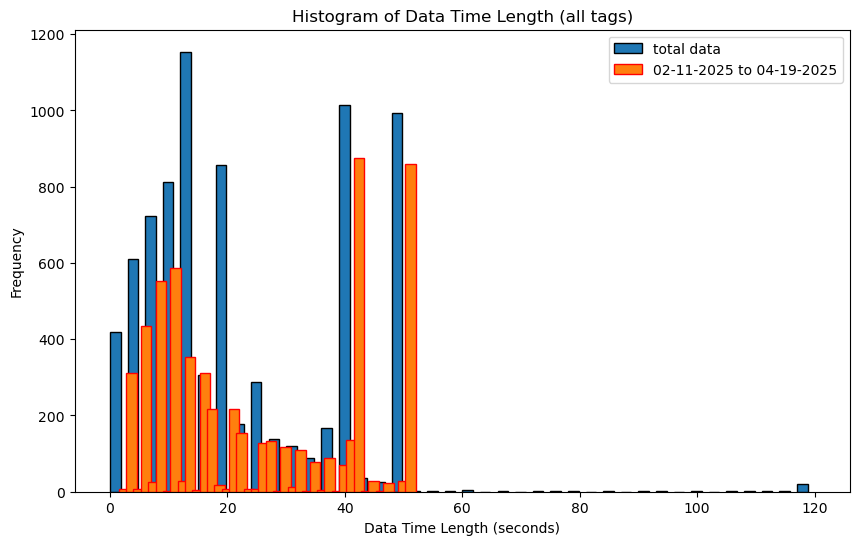

In [226]:
plt.figure(figsize=(10, 6))
# plt.hist(data_time_length_df['data_time_length_sec'], bins=40, edgecolor='black', label='total data')
# Calculate the width of each bin
bin_width = (data_time_length_df['data_time_length_sec'].max() - data_time_length_df['data_time_length_sec'].min()) / 40
bar_width = bin_width * 0.6  # Decrease the width of each bar
bin_width = (data_time_length_df['data_time_length_sec'].max() - data_time_length_df['data_time_length_sec'].min()) / 40

# Plot the histogram for the total data
plt.hist(data_time_length_df['data_time_length_sec'], bins=40, edgecolor='black', label='total data', alpha=1, width=bar_width)

# Plot the histogram for the data from 02-11-2025 to 02-19-2025, shifted by half a bin width
plt.hist(data_time_length_df[(data_time_length_df['data_time_length_sec'] >= 0) & 
                             (data_time_length_df['original_time'].dt.date >= datetime.date(2025, 2, 11)) & 
                             (data_time_length_df['original_time'].dt.date <= datetime.date(2025, 4, 19))]['data_time_length_sec'] + bin_width / 2, 
         bins=40, edgecolor='red', alpha=1, label='02-11-2025 to 04-19-2025',width=bar_width)
plt.legend()
plt.xlabel('Data Time Length (seconds)')
plt.ylabel('Frequency')
plt.title('Histogram of Data Time Length (all tags)')
# plt.show()

In [86]:
data_time_length_df['original_time']

0       2025-01-16 15:14:06.200
1       2025-01-16 15:16:21.200
2       2025-01-16 15:16:54.200
3       2025-01-16 15:19:04.200
4       2025-01-16 15:20:57.200
                  ...          
10795   2025-02-18 22:21:07.200
10796   2025-02-18 22:26:28.540
10797   2025-02-18 22:30:55.200
10798   2025-02-18 22:31:51.200
10799   2025-02-18 22:33:30.200
Name: original_time, Length: 10800, dtype: datetime64[ns]

/tmp/ipykernel_3476401/3178004938.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.hist(data_time_length_df[data_time_length_df.bird_id==idb][(data_time_length_df['data_time_length_sec'] >= 0) &


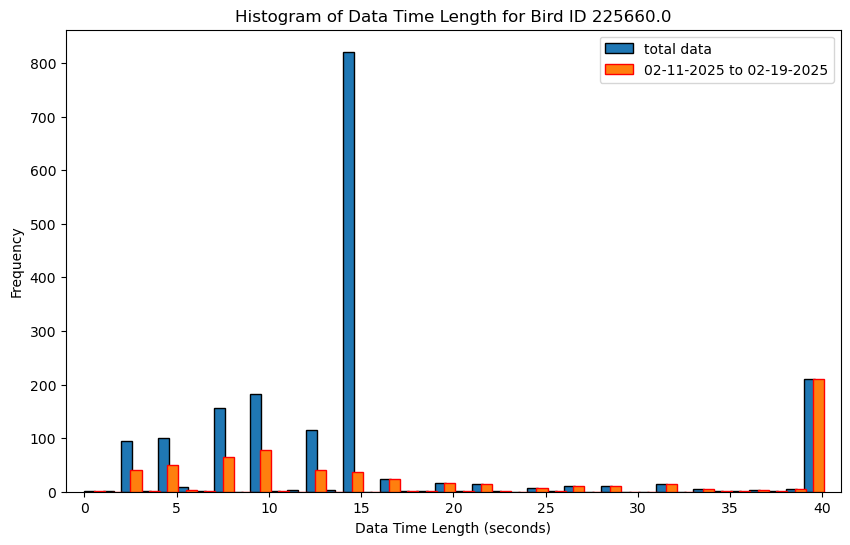

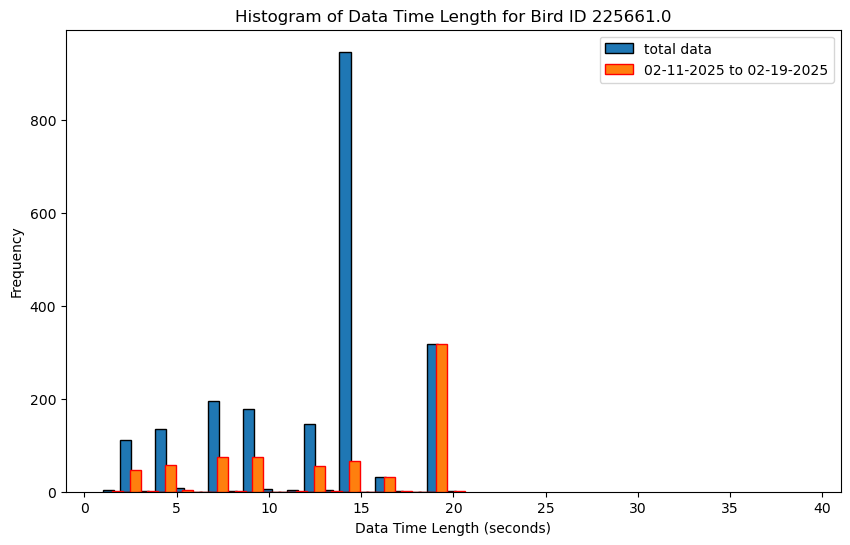

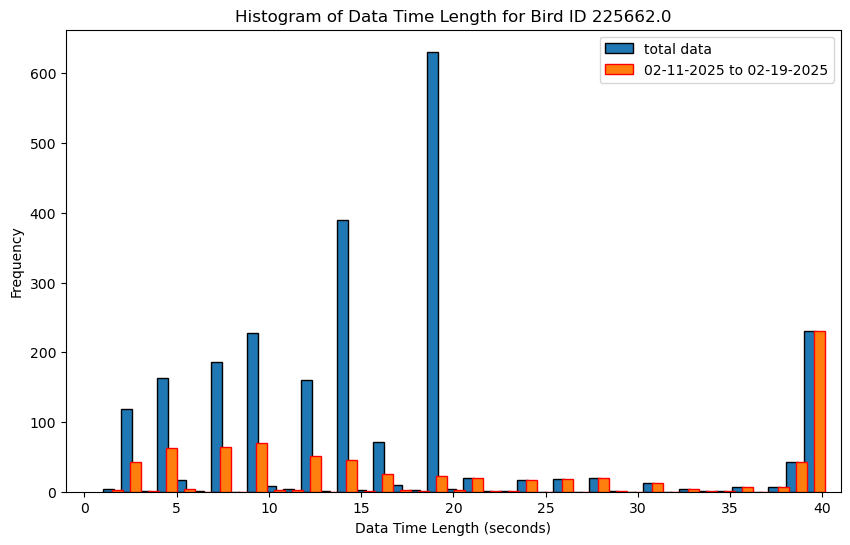

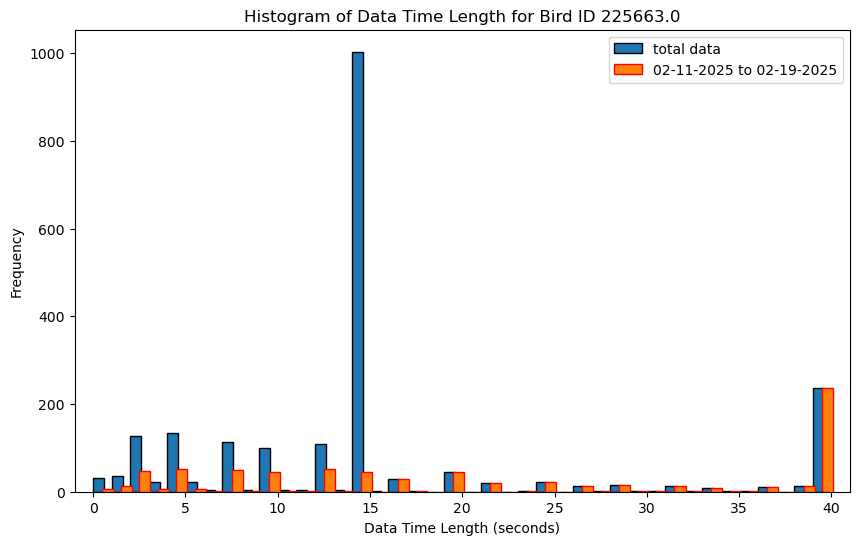

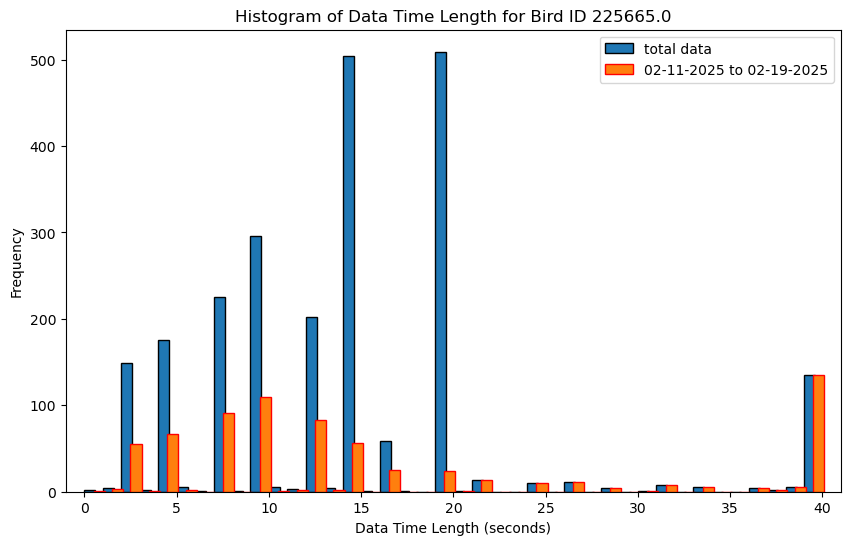

In [113]:
for idb in np.unique(data_time_length_df.bird_id):
    plt.figure(figsize=(10, 6))
    # plt.hist(data_time_length_df['data_time_length_sec'], bins=40, edgecolor='black', label='total data')
    # Calculate the width of each bin
    bin_width = (data_time_length_df['data_time_length_sec'].max() - data_time_length_df['data_time_length_sec'].min()) / 40
    bar_width = bin_width * 0.6  # Decrease the width of each bar

    # Plot the histogram for the total data
    plt.hist(data_time_length_df[data_time_length_df.bird_id==idb].data_time_length_sec, bins=40, edgecolor='black', label='total data', alpha=1, width=bar_width)

    # Plot the histogram for the data from 02-11-2025 to 02-19-2025, shifted by half a bin width
    plt.hist(data_time_length_df[data_time_length_df.bird_id==idb][(data_time_length_df['data_time_length_sec'] >= 0) & 
                                (data_time_length_df['original_time'].dt.date >= datetime.date(2025, 2, 11)) & 
                                (data_time_length_df['original_time'].dt.date <= datetime.date(2025, 2, 19))]['data_time_length_sec'] + bin_width / 2, 
            bins=40, edgecolor='red', alpha=1, label='02-11-2025 to 02-19-2025',width=bar_width)
    plt.legend()
    plt.xlabel('Data Time Length (seconds)')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Data Time Length for Bird ID {idb}')
    plt.xlim(-1,41)
    # plt.show()

## match to different tags in one day

In [158]:
data_40s_df
# Find the first and last original_time for each group with the same mask_ik
grouped_times = data_40s_df.groupby('chunk_id')['original_time'].agg(['first', 'last']).reset_index()

# Determine if there are overlaps between different mask_iks
overlaps = []
for i in range(len(grouped_times)):
    for j in range(i + 1, len(grouped_times)):
        if grouped_times['first'].iloc[i] <= grouped_times['last'].iloc[j] and grouped_times['last'].iloc[i] >= grouped_times['first'].iloc[j]:
            overlaps.append((grouped_times['chunk_id'].iloc[i], grouped_times['chunk_id'].iloc[j]))

print("Overlapping chunk_id pairs:", overlaps)

Overlapping chunk_id pairs: [(1210, 5328), (1217, 10184), (1221, 5334), (1249, 5336), (1249, 10198), (1250, 10203), (1282, 7746), (1287, 7750), (1297, 5391), (1328, 5400), (1340, 5406), (1449, 5527), (1450, 10433), (1462, 10438), (1473, 10447), (1494, 10510), (1496, 10513), (1509, 5575), (1518, 5581), (1524, 8260), (1537, 8265), (1597, 5808), (1601, 5821), (1619, 5861), (1620, 5863), (1627, 5869), (1689, 5889), (1693, 5893), (1712, 5916), (1758, 10796), (1811, 6023), (1823, 6039), (5326, 10075), (5336, 10198), (5486, 10333), (5495, 10344), (5535, 10460), (5538, 10463), (5547, 8051), (5568, 8121), (5677, 8307), (5702, 8331), (5711, 8335), (5741, 8355), (5778, 10648), (7719, 10072), (7822, 10282), (7824, 10283)]


In [161]:
data_40s_df[data_40s_df['chunk_id'].isin([1210,5328])]

,mask_ik,accz,bird_id,lon,lat,original_time,chunk_id,accy,accx
1200,195.0,962.0,225660.0,-78.9413833618164,-8.509385108947754,2025-02-12 14:38:23.200,1210,98.0,75.0
1201,195.0,1249.0,225660.0,-78.9413833618164,-8.509385108947754,2025-02-12 14:38:23.400,1210,134.0,18.0
1202,195.0,971.0,225660.0,-78.9413833618164,-8.509385108947754,2025-02-12 14:38:23.600,1210,92.0,138.0
1203,195.0,973.0,225660.0,-78.9413833618164,-8.509385108947754,2025-02-12 14:38:23.800,1210,205.0,108.0
1204,195.0,1090.0,225660.0,-78.9413833618164,-8.509385108947754,2025-02-12 14:38:24.000,1210,264.0,131.0
...,...,...,...,...,...,...,...,...,...
35795,866.0,994.0,225663.0,-78.94279479980467,-8.506571769714355,2025-02-12 14:39:21.200,5328,288.0,357.0
35796,866.0,937.0,225663.0,-78.94279479980467,-8.506571769714355,2025-02-12 14:39:21.400,5328,267.0,264.0
35797,866.0,965.0,225663.0,-78.94279479980467,-8.506571769714355,2025-02-12 14:39:21.600,5328,275.0,313.0
35798,866.0,925.0,225663.0,-78.94279479980467,-8.506571769714355,2025-02-12 14:39:21.800,5328,166.0,334.0


In [163]:
grouped_times[grouped_times['chunk_id'].isin([1210,5328])]

,chunk_id,first,last
6,1210,2025-02-12 14:38:23.200,2025-02-12 14:39:03.240
178,5328,2025-02-12 14:38:41.940,2025-02-12 14:39:22.000


In [76]:
for pair in overlaps:
    mask_ik_1, mask_ik_2 = pair
    data_1 = data_40s_df[data_40s_df['chunk_id'] == mask_ik_1]
    data_2 = data_40s_df[data_40s_df['chunk_id'] == mask_ik_2]

    fig = plt.figure(figsize=(12, 3))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
    
    axs = fig.add_subplot(gs[0])
    ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
    data_1_filter_2s = data_1['accz'].rolling(window=10, min_periods=1).mean()
    data_2_filter_2s = data_2['accz'].rolling(window=10, min_periods=1).mean()
    axs.plot(data_1['original_time'], data_1_filter_2s, label=f'accz_{mask_ik_1}')
    axs.plot(data_2['original_time'], data_2_filter_2s, label=f'accz_{mask_ik_2}')
    axs.set_title(f'Day: {data_1["original_time"].values[0]}')
    axs.set_ylim(0, 1500)
    axs.legend()
    
    ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
    plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
    ax_map.plot(data_1['lon'].iloc[0], data_1['lat'].iloc[0], 'ro')
    ax_map.plot(data_2['lon'].iloc[0], data_2['lat'].iloc[0], 'bo')
    ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
    ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
    ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
    ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
    ax_map.coastlines()
    ax_map.set_title('Location')
    ax_map.set_xlabel('Longitude')
    ax_map.set_ylabel('Latitude')
    # plt.show()

NameError: name 'overlaps' is not defined